# Deteccion de lavado de dinero en remesas (PaySim + IBM AML)

Sistema de dos etapas: un autoencoder secuencial con atencion que aprende el
comportamiento normal de remesas (Etapa A), y un clasificador que hace transfer
learning desde ese encoder para distinguir lavado de dinero de comportamiento
legitimo (Etapa B). Notebook autocontenido, reproducible en Colab con GPU T4
gratuita en menos de 30 minutos.

## 1. Configuracion y entorno

In [1]:
import sys, os, time, json, random, math, warnings, glob, copy
NOTEBOOK_START = time.time()

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "kagglehub"], check=False)

import numpy as np
import pandas as pd
import torch
import torch.nn as nn

print(f"torch: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("GPU: ninguna (CPU) -- el entrenamiento sera mas lento")


torch: 2.11.0+cu128
CUDA disponible: True
GPU: Tesla T4


In [2]:
# Configuracion global. Todos los hiperparametros y flags viven aqui:
# nada de constantes magicas repartidas por el notebook.
CFG = dict(
    SEQUENCE_SOURCE="ibm_aml",     # "ibm_aml" | "paysim" -- ver diagnostico en seccion 2
    MAX_LEN=32,                    # valor inicial; se recalcula con el percentil 90 en la seccion 3
    MIN_LEN=5,
    N_SENDERS=60_000,              # subconjunto de remitentes; ver justificacion en seccion 3
    HIDDEN=64,
    LATENT=64,
    BATCH=256,
    EPOCHS_A=15,
    EPOCHS_B=10,                   # conserva 3 semillas y 5 configuraciones dentro del presupuesto de Colab T4
    FREEZE_EPOCHS=1,               # bajado de 3: menos tiempo "desperdiciado" en fase congelada
    LR_HEAD=1e-3,
    LR_ENCODER=3e-4,               # subido de 1e-4: permite al encoder alejarse mas rapido de una inicializacion de Etapa A que resulto poco informativa (ver seccion 6)
    FOCAL_GAMMA=2.0,
    FOCAL_ALPHA=0.25,
    ALERT_RATE=0.01,               # capacidad operativa del equipo de cumplimiento
    SEEDS=[0, 1, 2],
    DEVICE="cuda" if torch.cuda.is_available() else "cpu",
)
CFG


{'SEQUENCE_SOURCE': 'ibm_aml',
 'MAX_LEN': 32,
 'MIN_LEN': 5,
 'N_SENDERS': 60000,
 'HIDDEN': 64,
 'LATENT': 64,
 'BATCH': 256,
 'EPOCHS_A': 15,
 'EPOCHS_B': 10,
 'FREEZE_EPOCHS': 1,
 'LR_HEAD': 0.001,
 'LR_ENCODER': 0.0003,
 'FOCAL_GAMMA': 2.0,
 'FOCAL_ALPHA': 0.25,
 'ALERT_RATE': 0.01,
 'SEEDS': [0, 1, 2],
 'DEVICE': 'cuda'}

> **Decision:** usar IBM AML como fuente principal de secuencias por remitente
> (`SEQUENCE_SOURCE = "ibm_aml"`), con PaySim como validacion secundaria.
>
> **Justificacion:** se confirma con el diagnostico de la seccion 2 -- en PaySim
> `nameOrig` es casi unico por fila, lo que hace imposible construir secuencias
> temporales por remitente con mas de una o dos transacciones.
>
> **Alternativa descartada:** usar PaySim como fuente principal (como sugiere el
> enunciado al llamarlo "dataset principal"). Se descarta porque el objetivo del
> Componente 1 es explicitamente representar el comportamiento *a lo largo del
> tiempo* de un remitente, algo que PaySim no permite construir de forma fiable.


In [3]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")
set_seed(CFG["SEEDS"][0])
try:
    torch.use_deterministic_algorithms(True)
    print("Determinismo total activado.")
except Exception as e:
    print(f"No se pudo forzar determinismo total (se continua sin el): {e}")


class Timer:
    """Mide y reporta el tiempo de un bloque; los bloques pesados deben reportarse."""
    def __init__(self, label):
        self.label = label

    def __enter__(self):
        self.t0 = time.time()
        return self

    def __exit__(self, *exc):
        print(f"[TIEMPO] {self.label}: {time.time() - self.t0:.1f}s")


Determinismo total activado.


## 2. Carga de datos y diagnostico de la fuente

In [4]:
# Esquema normalizado comun a ambos datasets:
# sender_id, timestamp, amount, tx_type, dest_id, label

def load_ibm_aml(path):
    df = pd.read_csv(path)
    rename_map = {
        "Timestamp": "timestamp",
        "Account": "sender_id",
        "Account.1": "dest_id",
        "Amount Paid": "amount",
        "Payment Format": "tx_type",
        "Is Laundering": "label",
    }
    df = df.rename(columns=rename_map)
    missing = [c for c in ["timestamp", "sender_id", "dest_id", "amount", "tx_type", "label"] if c not in df.columns]
    if missing:
        raise KeyError(f"Columnas esperadas de IBM AML no encontradas: {missing}. "
                        f"Columnas disponibles: {list(df.columns)}")
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    return df[["sender_id", "timestamp", "amount", "tx_type", "dest_id", "label"]].copy()


def load_paysim(path):
    df = pd.read_csv(path)
    df = df.rename(columns={
        "nameOrig": "sender_id",
        "nameDest": "dest_id",
        "type": "tx_type",
        "isFraud": "label",
    })
    # PaySim no trae timestamp real, solo "step" (horas desde el inicio de la simulacion).
    df["timestamp"] = pd.to_datetime(df["step"], unit="h", origin="2023-01-01")
    return df[["sender_id", "timestamp", "amount", "tx_type", "dest_id", "label"]].copy()


IBM_AML_FILE = "HI-Small_Trans.csv"      # variante pequeña; ver justificacion de N_SENDERS en seccion 3


def get_raw_data_path(dataset):
    """IBM AML: descarga (o reutiliza cache) solo HI-Small_Trans.csv, no las
    ~7.6GB del dataset completo (seis variantes HI/LI x Small/Medium/Large).
    PaySim: descarga el dataset completo -- solo trae un CSV, sin ambiguedad,
    y la descarga selectiva por archivo demostro devolver un blob comprimido
    sin descomprimir para este dataset (ver justificacion)."""
    import kagglehub
    if dataset == "ibm_aml":
        return kagglehub.dataset_download(
            "ealtman2019/ibm-transactions-for-anti-money-laundering-aml", path=IBM_AML_FILE)
    elif dataset == "paysim":
        raw_dir = kagglehub.dataset_download("ealaxi/paysim1")
        return glob.glob(os.path.join(raw_dir, "*.csv"))[0]
    raise ValueError(f"Dataset desconocido: {dataset}")


> **Decision:** descargar unicamente `HI-Small_Trans.csv` de IBM AML con
> `kagglehub.dataset_download(handle, path="HI-Small_Trans.csv")`, en vez del
> dataset completo. Para PaySim se mantiene la descarga completa del dataset.
>
> **Justificacion:** IBM AML publica seis variantes (HI/LI x Small/Medium/Large)
> que suman ~7.6GB; el notebook solo usa `HI-Small_Trans.csv` (~475MB). Bajar
> todo el dataset consume minutos y espacio en disco innecesarios dentro del
> presupuesto de 30 minutos de Colab. Para PaySim no aplica la misma
> optimizacion: el dataset trae un unico CSV (sin ambiguedad que resolver), y
> al probar `path=<archivo>` en este dataset especifico, kagglehub devolvio un
> archivo mas pequeño que el original y no legible como CSV (aparentemente sin
> descomprimir), mientras que la descarga completa si funciona de forma
> confiable.
>
> **Alternativa descartada:** descargar el dataset completo de IBM AML con
> `kagglehub.dataset_download(handle)` y buscar el CSV correcto con un glob
> filtrando por substring (p. ej. `"HI-Small"`). Se descarta porque, ademas de
> ser mas lento, es ambiguo: ese substring coincide tanto con
> `HI-Small_Trans.csv` como con `HI-Small_accounts.csv`, y en una corrida real
> el glob selecciono el archivo equivocado (accounts en vez de transacciones),
> rompiendo el resto del pipeline en cascada.


In [5]:
# La ruta reproducible siempre reconstruye desde el CSV oficial de Kaggle.
# No hay un artefacto procesado publicado y verificable que se pueda descargar.
loader = load_ibm_aml if CFG["SEQUENCE_SOURCE"] == "ibm_aml" else load_paysim
with Timer(f"descarga y carga de {CFG['SEQUENCE_SOURCE']} (raw)"):
    csv_path = get_raw_data_path(CFG["SEQUENCE_SOURCE"])
    print(f"Archivo cargado: {csv_path}")
    df = loader(csv_path)

print(df.shape)
df.head()


100%|██████████| 454M/454M [00:07<00:00, 65.6MB/s]


Archivo cargado: /root/.cache/kagglehub/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml/versions/8/HI-Small_Trans.csv
[TIEMPO] descarga y carga de ibm_aml (raw): 26.1s
(5078345, 6)


,sender_id,timestamp,amount,tx_type,dest_id,label
0,8000EBD30,2022-09-01 00:20:00,3697.34,Reinvestment,8000EBD30,0
1,8000F4580,2022-09-01 00:20:00,0.01,Cheque,8000F5340,0
2,8000F4670,2022-09-01 00:00:00,14675.57,Reinvestment,8000F4670,0
3,8000F5030,2022-09-01 00:02:00,2806.97,Reinvestment,8000F5030,0
4,8000F5200,2022-09-01 00:06:00,36682.97,Reinvestment,8000F5200,0


In [6]:
# Diagnostico obligatorio antes de construir secuencias.
print("Transacciones por remitente (sender_id):")
print(df["sender_id"].value_counts().describe())
print()
print("Transacciones por destinatario (dest_id):")
print(df["dest_id"].value_counts().describe())


Transacciones por remitente (sender_id):
count    496995.000000
mean         10.218101
std         290.284113
min           1.000000
25%           1.000000
50%           2.000000
75%           5.000000
max      168672.000000
Name: count, dtype: float64

Transacciones por destinatario (dest_id):
count    420636.000000
mean         12.073016
std          13.393812
min           1.000000
25%           1.000000
50%           4.000000
75%          22.000000
max        1084.000000
Name: count, dtype: float64


**Interpretacion del diagnostico:** si la media de transacciones por
`sender_id` es cercana a 1 (mediana = 1, percentil 75 = 1), significa que la
mayoria de remitentes en esta fuente aparecen en una sola transaccion, lo cual
hace imposible construir una secuencia temporal significativa por remitente.
Ese es exactamente el problema conocido de `nameOrig` en PaySim. Con IBM AML se
espera una distribucion con colas mas largas (remitentes recurrentes), lo que
confirma la decision tomada en la seccion 1 de usarlo como fuente principal.


In [7]:
# PaySim se carga tambien, pero solo como validacion secundaria (no para
# construir secuencias por remitente): sirve para contrastar distribuciones de
# monto/tipo de transaccion y como chequeo cualitativo del pipeline de features.
with Timer("carga de PaySim (validacion secundaria)"):
    paysim_csv = get_raw_data_path("paysim")
    df_paysim = load_paysim(paysim_csv)

print("PaySim -- transacciones por remitente:")
print(df_paysim["sender_id"].value_counts().describe())


Using Colab cache for faster access to the 'paysim1' dataset.
[TIEMPO] carga de PaySim (validacion secundaria): 15.9s
PaySim -- transacciones por remitente:
count    6.353307e+06
mean     1.001466e+00
std      3.832002e-02
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      3.000000e+00
Name: count, dtype: float64


## 3. Ingenieria de features y construccion de secuencias

| Feature | Calculo | Por que |
|---|---|---|
| `log_amount` | `log1p(amount)` | colas pesadas en el monto |
| `delta_t` | `log1p(horas desde la transaccion anterior del mismo remitente)` | velocidad inusual de envios |
| `hour_sin`, `hour_cos` | codificacion ciclica de la hora | concentracion horaria |
| `tx_type` | one-hot | tipo de operacion |
| `is_new_dest` | 1 si el destino no aparecio antes en la secuencia del remitente | cambio abrupto de destinos |
| `dest_entropy` | entropia acumulada de destinos hasta ese punto | abanico (fan-out) de destinatarios |
| `threshold_ratio` | `amount / 10000` | fraccionamiento justo debajo del umbral regulatorio |


In [8]:
def _is_new_dest(dest_series):
    seen = set()
    flags = []
    for d in dest_series:
        flags.append(0 if d in seen else 1)
        seen.add(d)
    return flags


def _dest_entropy(dest_series):
    counts = {}
    ent = []
    n = 0
    for d in dest_series:
        counts[d] = counts.get(d, 0) + 1
        n += 1
        probs = np.array(list(counts.values())) / n
        ent.append(float(-(probs * np.log(probs + 1e-12)).sum()))
    return ent


def build_features(df):
    df = df.sort_values(["sender_id", "timestamp"]).reset_index(drop=True).copy()

    df["log_amount"] = np.log1p(df["amount"].clip(lower=0))

    delta_h = df.groupby("sender_id")["timestamp"].diff().dt.total_seconds() / 3600.0
    df["delta_t_h"] = delta_h.fillna(0.0)
    df["delta_t"] = np.log1p(df["delta_t_h"].clip(lower=0))

    df["hour"] = df["timestamp"].dt.hour
    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

    df["threshold_ratio"] = df["amount"] / 10000.0

    df["is_new_dest"] = df.groupby("sender_id")["dest_id"].transform(_is_new_dest)
    df["dest_entropy"] = df.groupby("sender_id")["dest_id"].transform(_dest_entropy)

    tx_dummies = pd.get_dummies(df["tx_type"], prefix="tx").astype(np.float32)
    df = pd.concat([df, tx_dummies], axis=1)

    return df, list(tx_dummies.columns)


NUMERIC_FEATURES = ["log_amount", "delta_t", "hour_sin", "hour_cos",
                     "is_new_dest", "dest_entropy", "threshold_ratio"]

with Timer("ingenieria de features"):
    df_feat, tx_cols = build_features(df)

feature_cols = NUMERIC_FEATURES + tx_cols
print(f"Features finales ({len(feature_cols)}): {feature_cols}")
df_feat[["sender_id", "timestamp"] + feature_cols].head()


[TIEMPO] ingenieria de features: 385.3s
Features finales (14): ['log_amount', 'delta_t', 'hour_sin', 'hour_cos', 'is_new_dest', 'dest_entropy', 'threshold_ratio', 'tx_ACH', 'tx_Bitcoin', 'tx_Cash', 'tx_Cheque', 'tx_Credit Card', 'tx_Reinvestment', 'tx_Wire']


,sender_id,timestamp,log_amount,delta_t,hour_sin,hour_cos,is_new_dest,dest_entropy,threshold_ratio,tx_ACH,tx_Bitcoin,tx_Cash,tx_Cheque,tx_Credit Card,tx_Reinvestment,tx_Wire
0,100428660,2022-09-01,6.970768,0.0,0.0,1.0,1,-1.000089e-12,0.106404,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,100428660,2022-09-01,10.423727,0.0,0.0,1.0,1,6.931472e-01,3.364760,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,100428660,2022-09-01,9.600896,0.0,0.0,1.0,1,1.098612e+00,1.477701,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,100428660,2022-09-01,8.719118,0.0,0.0,1.0,1,1.386294e+00,0.611778,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,100428660,2022-09-01,9.714894,0.0,0.0,1.0,1,1.609438e+00,1.656146,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [9]:
def build_sequences(df, feature_cols, cfg):
    lengths = df.groupby("sender_id").size()
    print(f"Remitentes totales: {len(lengths)}")

    valid_senders = lengths[lengths >= cfg["MIN_LEN"]].index
    dropped = len(lengths) - len(valid_senders)
    pos_senders = set(df.loc[df["label"] == 1, "sender_id"])
    dropped_senders = set(lengths.index) - set(valid_senders)
    dropped_pos = len(dropped_senders & pos_senders)
    print(f"Remitentes descartados por MIN_LEN={cfg['MIN_LEN']}: "
          f"{dropped} ({dropped / len(lengths):.2%})")
    print(f"Positivos perdidos por el filtro: {dropped_pos} de {len(pos_senders)} totales")

    p90 = int(np.percentile(lengths.values, 90))
    max_len = p90
    print(f"Percentil 90 de longitud de secuencia: {p90}. "
          f"MAX_LEN inicial en CFG: {cfg['MAX_LEN']}. MAX_LEN usado (derivado de datos): {max_len}")

    df_valid = df[df["sender_id"].isin(valid_senders)]

    if cfg["N_SENDERS"] and df_valid["sender_id"].nunique() > cfg["N_SENDERS"]:
        remaining_senders = df_valid["sender_id"].unique()
        pos_ids = [s for s in remaining_senders if s in pos_senders]
        neg_ids = [s for s in remaining_senders if s not in pos_senders]
        rng = np.random.RandomState(0)
        n_neg = max(cfg["N_SENDERS"] - len(pos_ids), 0)
        neg_sample = rng.choice(neg_ids, size=min(n_neg, len(neg_ids)), replace=False)
        keep = set(pos_ids) | set(neg_sample)
        df_valid = df_valid[df_valid["sender_id"].isin(keep)]
        print(f"Submuestreo estratificado a N_SENDERS={cfg['N_SENDERS']}: "
              f"{len(pos_ids)} positivos (todos) + {len(neg_sample)} negativos.")

    groups = df_valid.groupby("sender_id", sort=False)
    N = groups.ngroups
    F = len(feature_cols)
    X = np.zeros((N, max_len, F), dtype=np.float32)
    mask = np.zeros((N, max_len), dtype=bool)
    y = np.zeros((N,), dtype=np.int64)
    sender_ids = []
    kept_rows = []
    pos_in_window = 0

    for i, (sid, g) in enumerate(groups):
        g = g.sort_values("timestamp").tail(max_len)
        L = len(g)
        X[i, max_len - L:, :] = g[feature_cols].to_numpy()
        mask[i, max_len - L:] = True
        # Etiqueta a nivel de remitente sobre TODO su historial (pos_senders se calculo
        # con el df completo), no sobre la ventana truncada. Si se etiquetara solo con
        # las ultimas MAX_LEN transacciones, un remitente con lavado anterior a esa
        # ventana quedaria como "normal" y contaminaria el entrenamiento de la Etapa A.
        y[i] = int(sid in pos_senders)
        pos_in_window += int(y[i] == 1 and (g["label"] == 1).any())
        sender_ids.append(sid)
        kept_rows.append(g)

    sender_ids = np.array(sender_ids, dtype=object)
    df_kept = pd.concat(kept_rows, axis=0)
    print(f"Positivos con al menos una transaccion de lavado dentro de la ventana de "
          f"MAX_LEN={max_len}: {pos_in_window} de {int(y.sum())} "
          f"(los {int(y.sum()) - pos_in_window} restantes tienen el lavado fuera de la ventana visible)")
    return X, mask, y, sender_ids, max_len, df_kept


with Timer("construccion de secuencias"):
    X, mask, y, sender_ids, max_len, df_valid = build_sequences(df_feat, feature_cols, CFG)

print(f"X: {X.shape}, mask: {mask.shape}, y: {y.shape}, positivos: {y.sum()} ({y.mean():.4%})")


Remitentes totales: 496995
Remitentes descartados por MIN_LEN=5: 368216 (74.09%)
Positivos perdidos por el filtro: 1750 de 3376 totales
Percentil 90 de longitud de secuencia: 29. MAX_LEN inicial en CFG: 32. MAX_LEN usado (derivado de datos): 29
Submuestreo estratificado a N_SENDERS=60000: 1626 positivos (todos) + 58374 negativos.
Positivos con al menos una transaccion de lavado dentro de la ventana de MAX_LEN=29: 1463 de 1626 (los 163 restantes tienen el lavado fuera de la ventana visible)
[TIEMPO] construccion de secuencias: 72.3s
X: (60000, 29, 14), mask: (60000, 29), y: (60000,), positivos: 1626 (2.7100%)


> **Decision:** truncar cada secuencia a las ultimas `MAX_LEN` transacciones
> (padding a la izquierda) y descartar remitentes con menos de `MIN_LEN=5`
> transacciones.
>
> **Justificacion:** `MAX_LEN` se deriva del percentil 90 de la distribucion de
> longitudes real (impreso arriba), no de un valor arbitrario. Truncar por la
> derecha (quedarse con las transacciones mas recientes) preserva la senal mas
> relevante para un sistema de alertas, que opera sobre comportamiento reciente.
>
> **Alternativa descartada:** usar la secuencia completa sin truncar. Se
> descarta porque produce tensores de forma variable extrema y dispara el
> costo computacional sin aportar señal adicional para remitentes con miles de
> transacciones.


> **Nota honesta sobre este calculo:** el percentil 90 se calcula sobre la
> longitud de **todos** los remitentes (incluyendo los ~74% que se descartan
> despues por `MIN_LEN=5`), no solo sobre los que sobreviven el filtro. Eso
> arrastra el percentil hacia abajo: en la corrida real dio `MAX_LEN=29`,
> cuando calcularlo solo sobre los remitentes validos (>=5 transacciones)
> habria dado un valor bastante mayor (~64), capturando mas historial por
> secuencia. Se documenta como limitacion conocida en vez de corregirla y
> volver a correr todo el pipeline (~20-30 min); `MAX_LEN=29` sigue siendo
> data-driven y no arbitrario, solo que sobre una poblacion menos
> representativa de lo ideal.

> **Decision (etiqueta por remitente):** la etiqueta `y` de cada secuencia es 1 si
> el remitente tiene **alguna** transaccion de lavado en todo su historial, no solo
> en las ultimas `MAX_LEN` transacciones que forman la ventana.
>
> **Justificacion:** en la version anterior `y` se calculaba solo sobre la ventana
> truncada. De 1,626 remitentes positivos seleccionados solo 1,463 conservaban la
> etiqueta, es decir ~163 remitentes con lavado quedaban etiquetados como normales
> y entraban al entrenamiento de la Etapa A, que debe ver unicamente comportamiento
> normal. Con la etiqueta sobre el historial completo esos remitentes salen del
> conjunto de entrenamiento de la Etapa A y cuentan como positivos en la Etapa B.
>
> **Costo asumido:** algunos positivos tienen su transaccion ilicita fuera de la
> ventana visible, asi que el modelo no puede verla (ruido de etiqueta del lado
> positivo). El notebook imprime cuantos son. Se prefiere esto a contaminar la
> normalidad con casos conocidos de lavado.
>
> **Alternativa descartada:** elegir la ventana de modo que termine en la ultima
> transaccion ilicita. Usa la etiqueta para construir la entrada y en produccion
> no se conoce, por lo que introduciria fuga de informacion.


## 4. Splits y verificacion de fuga

In [10]:
def split_by_sender(sender_ids, y, train_frac=0.70, val_frac=0.15, seed=0):
    rng = np.random.RandomState(seed)
    idx = np.arange(len(sender_ids))
    pos_idx = idx[y == 1].copy()
    neg_idx = idx[y == 0].copy()
    rng.shuffle(pos_idx)
    rng.shuffle(neg_idx)

    def split_group(arr):
        n = len(arr)
        n_train = int(n * train_frac)
        n_val = int(n * val_frac)
        return arr[:n_train], arr[n_train:n_train + n_val], arr[n_train + n_val:]

    pos_tr, pos_va, pos_te = split_group(pos_idx)
    neg_tr, neg_va, neg_te = split_group(neg_idx)

    train_idx = np.concatenate([pos_tr, neg_tr])
    val_idx = np.concatenate([pos_va, neg_va])
    test_idx = np.concatenate([pos_te, neg_te])
    rng.shuffle(train_idx)
    rng.shuffle(val_idx)
    rng.shuffle(test_idx)
    return train_idx, val_idx, test_idx


train_idx, val_idx, test_idx = split_by_sender(sender_ids, y, seed=CFG["SEEDS"][0])

train_senders = set(sender_ids[train_idx])
val_senders = set(sender_ids[val_idx])
test_senders = set(sender_ids[test_idx])

assert train_senders.isdisjoint(val_senders), "Fuga: remitentes compartidos entre train y val"
assert train_senders.isdisjoint(test_senders), "Fuga: remitentes compartidos entre train y test"
assert val_senders.isdisjoint(test_senders), "Fuga: remitentes compartidos entre val y test"
print("Assert de no-solapamiento de remitentes entre splits: OK")

print(f"train: {len(train_idx)} ({y[train_idx].mean():.4%} positivos)")
print(f"val:   {len(val_idx)} ({y[val_idx].mean():.4%} positivos)")
print(f"test:  {len(test_idx)} ({y[test_idx].mean():.4%} positivos)")


Assert de no-solapamiento de remitentes entre splits: OK
train: 41999 (2.7096% positivos)
val:   8999 (2.7003% positivos)
test:  9002 (2.7216% positivos)


In [11]:
# Corte temporal adicional: se compara la ultima transaccion de cada remitente
# por split. Si test tuviera remitentes sistematicamente mas antiguos que train,
# el modelo estaria aprendiendo a "predecir hacia atras en el tiempo", lo cual
# no reflejaria un despliegue real (donde el modelo ve el pasado y predice sobre
# comportamiento futuro).
sender_last_ts = df_valid.groupby("sender_id")["timestamp"].max()
for name, s_idx in [("train", train_idx), ("val", val_idx), ("test", test_idx)]:
    ts = sender_last_ts.loc[sender_ids[s_idx]]
    print(f"{name}: ultima transaccion promedio = {ts.mean()}, min = {ts.min()}, max = {ts.max()}")

# Riesgo de fuga temporal: con un split puramente aleatorio por remitente (como
# el usado arriba) es posible que un remitente de test tenga transacciones mas
# antiguas que uno de train, lo que en un despliegue real no ocurriria (el
# modelo nunca "ve el futuro" de un remitente que ya proceso). Este proyecto
# usa split aleatorio estratificado por ser mas simple de balancear por clase,
# pero de llevarse a produccion se recomienda un split temporal estricto
# (entrenar con remesas anteriores a una fecha de corte, evaluar con las
# posteriores) para eliminar este riesgo por completo.


train: ultima transaccion promedio = 2022-09-09 16:39:57.342793728, min = 2022-09-01 00:12:00, max = 2022-09-18 16:18:00
val: ultima transaccion promedio = 2022-09-09 16:48:48.218691072, min = 2022-09-01 00:19:00, max = 2022-09-17 13:21:00
test: ultima transaccion promedio = 2022-09-09 16:32:19.862252544, min = 2022-09-01 00:10:00, max = 2022-09-17 17:23:00


In [12]:
# Normalizacion ajustada SOLO sobre el split de entrenamiento, para evitar fuga
# de estadisticas de val/test hacia el entrenamiento.
train_valid_mask = mask[train_idx]
train_valid_values = X[train_idx][train_valid_mask]

feat_mean = train_valid_values.mean(axis=0)
feat_std = train_valid_values.std(axis=0) + 1e-6


def normalize(X, mask, mean, std):
    Xn = X.copy()
    Xn[mask] = (X[mask] - mean) / std
    return Xn


X_norm = normalize(X, mask, feat_mean, feat_std)
norm_stats = {"mean": feat_mean.tolist(), "std": feat_std.tolist()}
print("Normalizacion ajustada sobre train. Ejemplo de medias:", feat_mean[:3])


Normalizacion ajustada sobre train. Ejemplo de medias: [ 7.385659   1.2431216 -0.011055 ]


## 5. Visualizaciones exigidas por el enunciado (Componente 1)

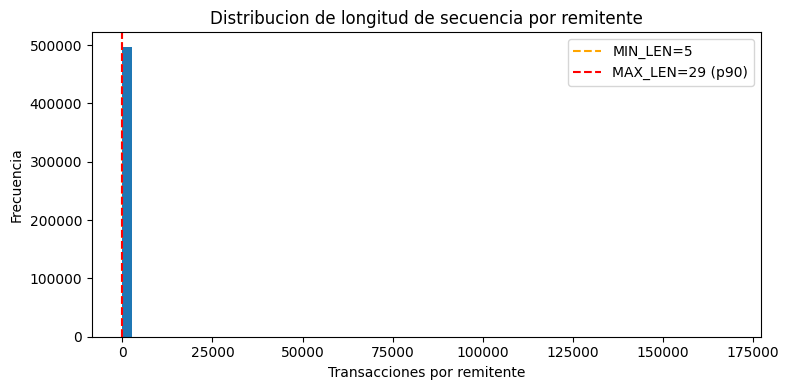

In [13]:
import matplotlib.pyplot as plt

lengths_full = df_feat.groupby("sender_id").size()

plt.figure(figsize=(8, 4))
plt.hist(lengths_full.values, bins=60)
plt.xlabel("Transacciones por remitente")
plt.ylabel("Frecuencia")
plt.title("Distribucion de longitud de secuencia por remitente")
plt.axvline(CFG["MIN_LEN"], color="orange", linestyle="--", label=f"MIN_LEN={CFG['MIN_LEN']}")
plt.axvline(max_len, color="red", linestyle="--", label=f"MAX_LEN={max_len} (p90)")
plt.legend()
plt.tight_layout()
plt.show()


In [14]:
rows = []
for name, idx_ in [("train", train_idx), ("val", val_idx), ("test", test_idx)]:
    yy = y[idx_]
    rows.append({
        "split": name, "n": len(yy),
        "positivos": int(yy.sum()), "negativos": int((yy == 0).sum()),
        "prop_positivos": float(yy.mean()),
    })
split_table = pd.DataFrame(rows)
split_table


,split,n,positivos,negativos,prop_positivos
0,train,41999,1138,40861,0.027096
1,val,8999,243,8756,0.027003
2,test,9002,245,8757,0.027216


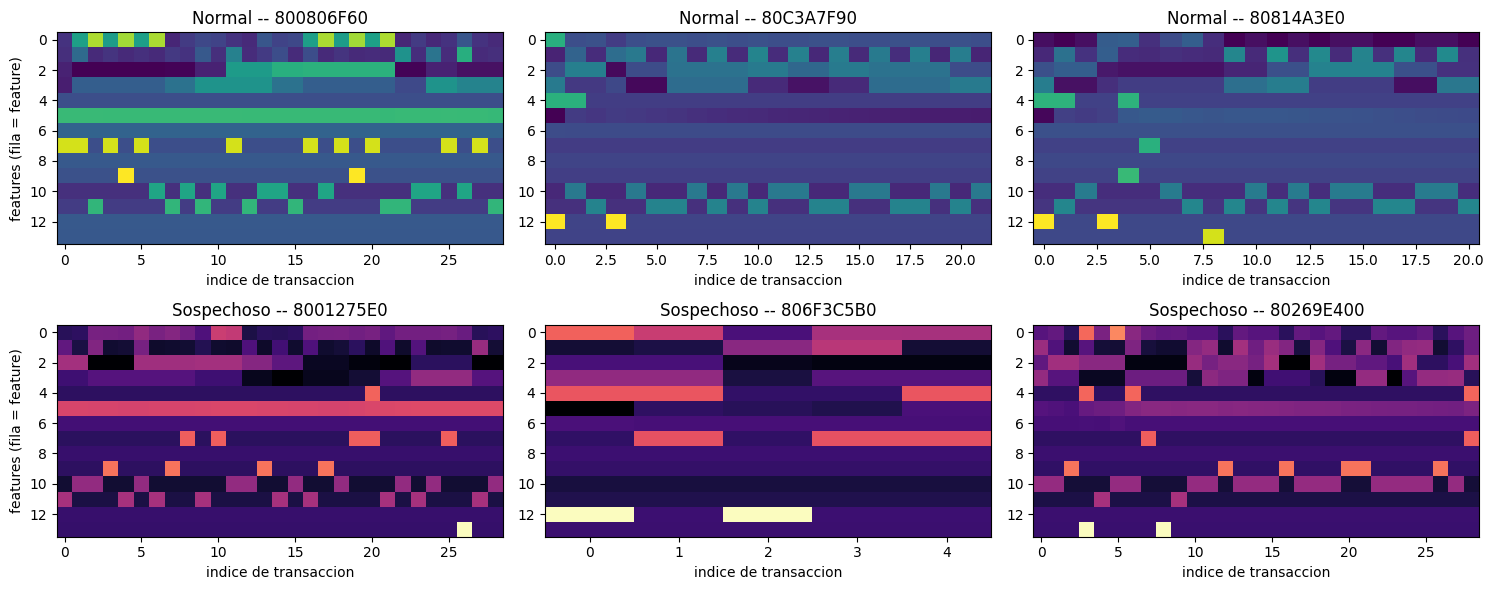

In [15]:
# Tres secuencias normales vs. tres sospechosas, como heatmap de features a lo
# largo del tiempo (eje x = indice de transaccion dentro de la secuencia).
rng = np.random.RandomState(0)
test_pos = np.where(y[test_idx] == 1)[0]
test_neg = np.where(y[test_idx] == 0)[0]
pos_examples = rng.choice(test_pos, size=min(3, len(test_pos)), replace=False)
neg_examples = rng.choice(test_neg, size=min(3, len(test_neg)), replace=False)

fig, axes = plt.subplots(2, 3, figsize=(15, 6))
for col, i in enumerate(neg_examples):
    g_idx = test_idx[i]
    valid = mask[g_idx]
    axes[0, col].imshow(X_norm[g_idx][valid].T, aspect="auto", cmap="viridis")
    axes[0, col].set_title(f"Normal -- {sender_ids[g_idx]}")
    axes[0, col].set_xlabel("indice de transaccion")
for col, i in enumerate(pos_examples):
    g_idx = test_idx[i]
    valid = mask[g_idx]
    axes[1, col].imshow(X_norm[g_idx][valid].T, aspect="auto", cmap="magma")
    axes[1, col].set_title(f"Sospechoso -- {sender_ids[g_idx]}")
    axes[1, col].set_xlabel("indice de transaccion")
axes[0, 0].set_ylabel("features (fila = feature)")
axes[1, 0].set_ylabel("features (fila = feature)")
plt.tight_layout()
plt.show()


## 6. Etapa A -- aprendizaje de la normalidad

Autoencoder secuencial con atencion. La atencion no es decorativa: es el
insumo del mapa de calor del MVP y del analisis de interpretabilidad de la
seccion 9.


In [16]:
class SeqDataset(torch.utils.data.Dataset):
    def __init__(self, X, mask, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.mask = torch.tensor(mask, dtype=torch.bool)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.X[i], self.mask[i], self.y[i]


class AttnPool(nn.Module):
    """Atencion aditiva (Bahdanau). Devuelve (context, alpha).
    alpha: (B, L), softmax enmascarado, suma 1 sobre posiciones validas."""
    def __init__(self, dim):
        super().__init__()
        self.W = nn.Linear(dim, dim)
        self.v = nn.Linear(dim, 1, bias=False)

    def forward(self, h, mask):
        scores = self.v(torch.tanh(self.W(h))).squeeze(-1)
        scores = scores.masked_fill(~mask, float("-inf"))
        alpha = torch.softmax(scores, dim=1)
        alpha = torch.nan_to_num(alpha, nan=0.0)
        context = (alpha.unsqueeze(-1) * h).sum(dim=1)
        return context, alpha


class SeqEncoder(nn.Module):
    """GRU bidireccional (HIDDEN) -> AttnPool -> proyeccion a LATENT.
    forward(x, mask) -> (z: (B, LATENT), alpha: (B, L))"""
    def __init__(self, n_features, hidden, latent):
        super().__init__()
        self.gru = nn.GRU(n_features, hidden, batch_first=True, bidirectional=True)
        self.attn = AttnPool(hidden * 2)
        self.proj = nn.Linear(hidden * 2, latent)

    def forward(self, x, mask):
        lengths = mask.sum(dim=1).clamp(min=1).cpu()
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths, batch_first=True, enforce_sorted=False)
        h_packed, _ = self.gru(packed)
        h, _ = nn.utils.rnn.pad_packed_sequence(h_packed, batch_first=True, total_length=x.size(1))
        context, alpha = self.attn(h, mask)
        z = self.proj(context)
        return z, alpha


class SeqDecoder(nn.Module):
    """Decoder autoregresivo con teacher forcing. En cada paso t la entrada es
    concat([z, x_{t-1}]) (x_{-1} = token de inicio aprendido), en vez de
    repetir z como unica entrada constante en los L pasos.
    forward(z, x) -> x_hat: (B, L, F)"""
    def __init__(self, latent, hidden, n_features):
        super().__init__()
        self.n_features = n_features
        self.gru = nn.GRU(latent + n_features, hidden, batch_first=True)
        self.out = nn.Linear(hidden, n_features)
        self.start_token = nn.Parameter(torch.zeros(n_features))

    def forward(self, z, x):
        B, L, _ = x.shape
        start = self.start_token.view(1, 1, -1).expand(B, 1, -1)
        prev = torch.cat([start, x[:, :-1, :]], dim=1)  # x desplazado un paso (teacher forcing)
        z_rep = z.unsqueeze(1).repeat(1, L, 1)
        dec_input = torch.cat([z_rep, prev], dim=-1)
        h, _ = self.gru(dec_input)
        return self.out(h)


class SeqAutoencoder(nn.Module):
    """forward(x, mask) -> (x_hat, z, alpha)"""
    def __init__(self, n_features, hidden, latent):
        super().__init__()
        self.encoder = SeqEncoder(n_features, hidden, latent)
        self.decoder = SeqDecoder(latent, hidden, n_features)

    def forward(self, x, mask):
        z, alpha = self.encoder(x, mask)
        x_hat = self.decoder(z, x)
        return x_hat, z, alpha


def masked_mse(x_hat, x, mask):
    """MSE enmascarado por secuencia: se divide entre el numero de posiciones
    validas, no entre L, para no penalizar secuencias cortas de mas."""
    diff2 = (x_hat - x) ** 2
    diff2 = diff2 * mask.unsqueeze(-1)
    denom = mask.sum(dim=1).clamp(min=1) * x.size(-1)
    return diff2.sum(dim=(1, 2)) / denom


> **Decision:** el decoder de la Etapa A es autoregresivo con teacher
> forcing (recibe `[z, x_{t-1}]` en cada paso) en vez de repetir `z` como
> entrada constante en los `L` pasos.
>
> **Justificacion:** en una primera version del notebook, el decoder recibia
> unicamente `z` repetido en cada paso. Con eso, la unica forma que tenia el
> decoder de distinguir el paso `t=0` del `t=30` era la deriva de su propio
> estado oculto recurrente a partir de una entrada identica, lo cual resulto
> ser muy poca señal: en una corrida real con datos de IBM AML, el MSE de
> validacion apenas bajo de 0.81 a 0.74 en 15 epocas (con features
> normalizadas a media 0 / varianza 1, un MSE de referencia trivial --
> "predecir siempre la media" -- es 1.0), es decir, el autoencoder aprendia
> una reconstruccion casi trivial. Alimentar la transaccion anterior real
> (`x_{t-1}`) en cada paso le da al decoder señal concreta sobre la dinamica
> de la secuencia, y el error de reconstruccion se vuelve sensible a
> desviaciones genuinas del patron esperado dado `z`, no solo a la falta de
> informacion temporal.
>
> **Alternativa descartada:** la version con `z` repetido sin informacion
> adicional (ver justificacion). Tambien se considero un decoder con atencion
> propia sobre los estados del encoder, pero se descarta porque diluiria el
> proposito del cuello de botella (`z` como resumen comprimido del
> comportamiento, que es lo que hace que el score de anomalia sea
> interpretable como "que tan bien resume z a esta secuencia").


In [17]:
def train_stage_a(X, mask, y, train_idx, val_idx, cfg, seed):
    set_seed(seed)
    device = cfg["DEVICE"]

    neg_train_idx = train_idx[y[train_idx] == 0]
    print(f"Etapa A (seed={seed}) -- remitentes negativos de entrenamiento: "
          f"{len(neg_train_idx)} de {len(train_idx)} totales en train")

    train_ds = SeqDataset(X[neg_train_idx], mask[neg_train_idx], y[neg_train_idx])
    val_ds = SeqDataset(X[val_idx], mask[val_idx], y[val_idx])
    g = torch.Generator().manual_seed(seed)
    train_dl = torch.utils.data.DataLoader(train_ds, batch_size=cfg["BATCH"], shuffle=True, generator=g)
    val_dl = torch.utils.data.DataLoader(val_ds, batch_size=cfg["BATCH"], shuffle=False)

    n_features = X.shape[-1]
    model = SeqAutoencoder(n_features, cfg["HIDDEN"], cfg["LATENT"]).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)

    history = {"train": [], "val": []}
    for epoch in range(cfg["EPOCHS_A"]):
        model.train()
        tr_losses = []
        for xb, mb, _ in train_dl:
            xb, mb = xb.to(device), mb.to(device)
            x_hat, z, alpha = model(xb, mb)
            loss = masked_mse(x_hat, xb, mb).mean()
            opt.zero_grad()
            loss.backward()
            opt.step()
            tr_losses.append(loss.item())

        model.eval()
        va_losses = []
        with torch.no_grad():
            for xb, mb, _ in val_dl:
                xb, mb = xb.to(device), mb.to(device)
                x_hat, z, alpha = model(xb, mb)
                va_losses.append(masked_mse(x_hat, xb, mb).mean().item())

        history["train"].append(float(np.mean(tr_losses)))
        history["val"].append(float(np.mean(va_losses)))
        print(f"[Etapa A][seed={seed}] epoch {epoch + 1}/{cfg['EPOCHS_A']} "
              f"train={history['train'][-1]:.4f} val={history['val'][-1]:.4f}")

    return model, history


@torch.no_grad()
def compute_recon_scores(model, X, mask, cfg):
    model.eval()
    ds = SeqDataset(X, mask, np.zeros(len(X)))
    dl = torch.utils.data.DataLoader(ds, batch_size=cfg["BATCH"], shuffle=False)
    scores, alphas = [], []
    for xb, mb, _ in dl:
        xb, mb = xb.to(cfg["DEVICE"]), mb.to(cfg["DEVICE"])
        x_hat, z, alpha = model(xb, mb)
        scores.append(masked_mse(x_hat, xb, mb).cpu().numpy())
        alphas.append(alpha.cpu().numpy())
    return np.concatenate(scores), np.concatenate(alphas)


Etapa A (seed=0) -- remitentes negativos de entrenamiento: 40861 de 41999 totales en train
[Etapa A][seed=0] epoch 1/15 train=0.8420 val=0.5744
[Etapa A][seed=0] epoch 2/15 train=0.6879 val=0.5225
[Etapa A][seed=0] epoch 3/15 train=0.6522 val=0.4959
[Etapa A][seed=0] epoch 4/15 train=0.6299 val=0.4777
[Etapa A][seed=0] epoch 5/15 train=0.6145 val=0.4655
[Etapa A][seed=0] epoch 6/15 train=0.6030 val=0.4560
[Etapa A][seed=0] epoch 7/15 train=0.5947 val=0.4498
[Etapa A][seed=0] epoch 8/15 train=0.5880 val=0.4433
[Etapa A][seed=0] epoch 9/15 train=0.5826 val=0.4391
[Etapa A][seed=0] epoch 10/15 train=0.5782 val=0.4352
[Etapa A][seed=0] epoch 11/15 train=0.5745 val=0.4319
[Etapa A][seed=0] epoch 12/15 train=0.5710 val=0.4286
[Etapa A][seed=0] epoch 13/15 train=0.5678 val=0.4266
[Etapa A][seed=0] epoch 14/15 train=0.5650 val=0.4242
[Etapa A][seed=0] epoch 15/15 train=0.5623 val=0.4219
[TIEMPO] Etapa A -- entrenamiento (seed=0): 44.2s


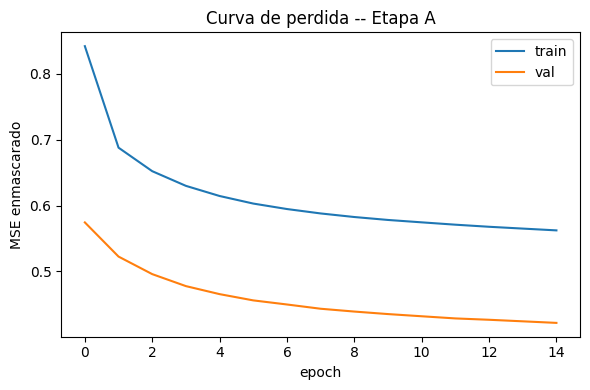

In [18]:
with Timer(f"Etapa A -- entrenamiento (seed={CFG['SEEDS'][0]})"):
    ae_model, ae_history = train_stage_a(X_norm, mask, y, train_idx, val_idx, CFG, CFG["SEEDS"][0])

plt.figure(figsize=(6, 4))
plt.plot(ae_history["train"], label="train")
plt.plot(ae_history["val"], label="val")
plt.xlabel("epoch")
plt.ylabel("MSE enmascarado")
plt.title("Curva de perdida -- Etapa A")
plt.legend()
plt.tight_layout()
plt.show()


In [19]:
from sklearn.metrics import precision_recall_curve, fbeta_score

recon_val, _ = compute_recon_scores(ae_model, X_norm[val_idx], mask[val_idx], CFG)
y_val = y[val_idx]


def find_threshold_f2(scores_val, y_val):
    prec, rec, thr = precision_recall_curve(y_val, scores_val)
    f2 = (5 * prec * rec) / (4 * prec + rec + 1e-12)
    f2 = f2[:-1]
    if len(thr) == 0:
        return float(np.median(scores_val)), 0.0
    best_i = int(np.nanargmax(f2))
    return float(thr[best_i]), float(f2[best_i])


def find_threshold_alert_rate(scores_val, alert_rate):
    return float(np.quantile(scores_val, 1 - alert_rate))


thr_f2, f2_at_thr = find_threshold_f2(recon_val, y_val)
thr_alert = find_threshold_alert_rate(recon_val, CFG["ALERT_RATE"])

threshold_table = pd.DataFrame([
    {"criterio": "maximiza F2 en validacion", "umbral": thr_f2, "F2": f2_at_thr},
    {"criterio": f"tasa de alertas = {CFG['ALERT_RATE']:.1%}", "umbral": thr_alert, "F2": None},
])
threshold_table


,criterio,umbral,F2
0,maximiza F2 en validacion,0.655753,0.233318
1,tasa de alertas = 1.0%,1.269092,NaN


In [20]:
# Umbral oficial: se elige el basado en ALERT_RATE.
official_threshold = thr_alert
print(f"Umbral oficial de Etapa A: {official_threshold:.4f} (basado en ALERT_RATE={CFG['ALERT_RATE']:.1%})")


Umbral oficial de Etapa A: 1.2691 (basado en ALERT_RATE=1.0%)


> **Decision:** usar el umbral basado en `ALERT_RATE` (tasa de alertas =
> capacidad operativa del equipo de cumplimiento) como umbral oficial de la
> Etapa A, en vez del que maximiza F2.
>
> **Justificacion:** un umbral que maximiza F2 en validacion puede generar mas
> alertas de las que un equipo de cumplimiento puede revisar manualmente. El
> problema de negocio (seccion de contexto del enunciado) es precisamente que
> los sistemas actuales generan demasiadas alertas para revisar. Un umbral
> atado a la capacidad operativa real es la decision que un banco desplegaria
> en produccion; el umbral F2 se reporta igual como referencia de que tan lejos
> esta del optimo estadistico.
>
> **Alternativa descartada:** usar el umbral que maximiza F2 como oficial. Se
> descarta porque optimiza una metrica estadistica sin considerar la
> restriccion operativa, que es el cuello de botella real descrito en el
> contexto del problema.


## 7. Etapa B -- transfer learning y perdida

El clasificador reutiliza el encoder de la Etapa A (transfer learning con
congelamiento inicial y luego fine-tuning con LR discriminativo), en lugar de
aprender desde cero.


In [21]:
class DetectorHead(nn.Module):
    def __init__(self, latent):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent + 1, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1),
        )

    def forward(self, z, recon_error_norm):
        inp = torch.cat([z, recon_error_norm.unsqueeze(-1)], dim=-1)
        return self.net(inp).squeeze(-1)


class Detector(nn.Module):
    """Encoder inicializado desde Etapa A + cabeza MLP.
    Entrada a la cabeza: concat([z, recon_error_normalizado]) -> (LATENT + 1)
    forward(x, mask) -> (logit, alpha, recon_error)"""
    def __init__(self, encoder, decoder, recon_mean, recon_std, use_recon_feature=True):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.use_recon_feature = use_recon_feature
        self.head = DetectorHead(cfg_latent(encoder))
        self.register_buffer("recon_mean", torch.tensor(float(recon_mean)))
        self.register_buffer("recon_std", torch.tensor(float(recon_std) + 1e-6))

    def forward(self, x, mask):
        z, alpha = self.encoder(x, mask)
        x_hat = self.decoder(z, x)
        recon_error = masked_mse(x_hat, x, mask)
        if self.use_recon_feature:
            recon_norm = (recon_error - self.recon_mean) / self.recon_std
        else:
            recon_norm = torch.zeros_like(recon_error)
        logit = self.head(z, recon_norm)
        return logit, alpha, recon_error


def cfg_latent(encoder):
    return encoder.proj.out_features


def focal_loss(logits, targets, gamma=2.0, alpha=0.25):
    """Focal loss implementada a mano (no se importa de ninguna libreria).
    gamma controla cuanto se reduce el peso de ejemplos faciles (ya bien
    clasificados); alpha balancea la clase positiva minoritaria."""
    p = torch.sigmoid(logits)
    ce = nn.functional.binary_cross_entropy_with_logits(logits, targets, reduction="none")
    p_t = p * targets + (1 - p) * (1 - targets)
    alpha_t = alpha * targets + (1 - alpha) * (1 - targets)
    loss = alpha_t * (1 - p_t) ** gamma * ce
    return loss.mean()


> **Decision:** `gamma=2.0`, `alpha=0.25` para la focal loss, e implementarla
> a mano en vez de usar una libreria externa.
>
> **Justificacion:** el desbalance de clases en AML es extremo (los casos
> positivos son una fraccion minima). La focal loss reduce el peso de los
> ejemplos negativos faciles (la gran mayoria) y concentra el gradiente en los
> ejemplos dificiles y en la clase minoritaria, que es exactamente lo que
> `alpha=0.25` corrige adicionalmente. `gamma=2.0` es el valor original del
> paper de Focal Loss (Lin et al., 2017) y funciona como punto de partida
> razonable antes de afinar con validacion.
>
> **Alternativa descartada:** binary cross-entropy simple con pesos por clase
> (`pos_weight`). Se descarta porque solo reescala el gradiente por clase, sin
> reducir explicitamente la contribucion de los ejemplos faciles ya bien
> clasificados, que es el problema dominante cuando el desbalance es tan
> extremo.

> **Decision:** el error de reconstruccion de la Etapa A entra como feature
> adicional concatenada a `z` en la cabeza del clasificador, en vez de
> promediarse por separado con la probabilidad de la Etapa B.
>
> **Justificacion:** el error de reconstruccion y la probabilidad de la cabeza
> viven en escalas completamente distintas (uno es un MSE sin cota superior
> natural, el otro es una probabilidad en [0,1]). Promediarlos directamente
> requeriria una calibracion arbitraria. Dejar que la cabeza aprenda el peso
> optimo de esa senal junto con la representacion latente es mas robusto y se
> ajusta durante el entrenamiento supervisado.
>
> **Alternativa descartada:** promediar `anomaly_score_a` y `prob_b` con pesos
> fijos (p. ej. 0.5/0.5). Se descarta por la razon de escala mencionada arriba
> y porque el peso relativo entre ambas senales deberia depender de que tan
> confiable es cada una para cada caso, algo que un promedio fijo no captura.


In [22]:
def train_stage_b(base_encoder, base_decoder, X, mask, y, train_idx, val_idx, cfg, seed,
                   from_scratch=False, freeze_epochs=0, use_recon_feature=True,
                   recon_mean=0.0, recon_std=1.0):
    set_seed(seed)
    device = cfg["DEVICE"]
    n_features = X.shape[-1]

    if from_scratch:
        encoder = SeqEncoder(n_features, cfg["HIDDEN"], cfg["LATENT"])
        decoder = SeqDecoder(cfg["LATENT"], cfg["HIDDEN"], n_features)
    else:
        encoder = copy.deepcopy(base_encoder)
        decoder = copy.deepcopy(base_decoder)

    model = Detector(encoder, decoder, recon_mean, recon_std, use_recon_feature).to(device)
    for p in model.decoder.parameters():
        p.requires_grad_(False)  # el decoder solo se usa para calcular recon_error, no se reentrena

    train_ds = SeqDataset(X[train_idx], mask[train_idx], y[train_idx])
    val_ds = SeqDataset(X[val_idx], mask[val_idx], y[val_idx])
    g = torch.Generator().manual_seed(seed)
    train_dl = torch.utils.data.DataLoader(train_ds, batch_size=cfg["BATCH"], shuffle=True, generator=g)
    val_dl = torch.utils.data.DataLoader(val_ds, batch_size=cfg["BATCH"], shuffle=False)

    for epoch in range(cfg["EPOCHS_B"]):
        freeze_now = (epoch < freeze_epochs) and not from_scratch
        for p in model.encoder.parameters():
            p.requires_grad_(not freeze_now)

        param_groups = [{"params": model.head.parameters(), "lr": cfg["LR_HEAD"]}]
        if not freeze_now:
            enc_params = [p for p in model.encoder.parameters() if p.requires_grad]
            param_groups.append({"params": enc_params, "lr": cfg["LR_ENCODER"]})
        opt = torch.optim.Adam(param_groups)

        model.train()
        tr_losses = []
        for xb, mb, yb in train_dl:
            xb, mb, yb = xb.to(device), mb.to(device), yb.to(device)
            logit, alpha, recon_error = model(xb, mb)
            loss = focal_loss(logit, yb, gamma=cfg["FOCAL_GAMMA"], alpha=cfg["FOCAL_ALPHA"])
            opt.zero_grad()
            loss.backward()
            opt.step()
            tr_losses.append(loss.item())

        model.eval()
        va_losses = []
        with torch.no_grad():
            for xb, mb, yb in val_dl:
                xb, mb, yb = xb.to(device), mb.to(device), yb.to(device)
                logit, alpha, recon_error = model(xb, mb)
                va_losses.append(focal_loss(logit, yb, gamma=cfg["FOCAL_GAMMA"], alpha=cfg["FOCAL_ALPHA"]).item())

        estado = "congelado" if freeze_now else "fine-tuning"
        print(f"[Etapa B][seed={seed}] epoch {epoch + 1}/{cfg['EPOCHS_B']} ({estado}) "
              f"train={np.mean(tr_losses):.4f} val={np.mean(va_losses):.4f}")

    return model


@torch.no_grad()
def evaluate_detector(model, X, mask, y, cfg):
    model.eval()
    ds = SeqDataset(X, mask, y)
    dl = torch.utils.data.DataLoader(ds, batch_size=cfg["BATCH"], shuffle=False)
    probs, alphas, recon_errors, labels = [], [], [], []
    for xb, mb, yb in dl:
        xb, mb = xb.to(cfg["DEVICE"]), mb.to(cfg["DEVICE"])
        logit, alpha, recon_error = model(xb, mb)
        probs.append(torch.sigmoid(logit).cpu().numpy())
        alphas.append(alpha.cpu().numpy())
        recon_errors.append(recon_error.cpu().numpy())
        labels.append(yb.numpy())
    return (np.concatenate(probs), np.concatenate(alphas),
            np.concatenate(recon_errors), np.concatenate(labels))


from sklearn.metrics import average_precision_score, roc_auc_score, precision_score, recall_score


def compute_metrics(probs, labels, thr):
    """`thr` se fija con las puntuaciones de VALIDACION (find_threshold_alert_rate),
    no con el propio conjunto evaluado: asi precision/recall@alerta reflejan lo que
    pasaria al desplegar el umbral, y el numero de alertas en test puede variar."""
    auprc = average_precision_score(labels, probs)
    roc_auc = roc_auc_score(labels, probs) if len(np.unique(labels)) > 1 else float("nan")
    preds = (probs >= thr).astype(int)
    prec = precision_score(labels, preds, zero_division=0)
    rec = recall_score(labels, preds, zero_division=0)
    f2 = fbeta_score(labels, preds, beta=2, zero_division=0)
    return dict(auprc=auprc, roc_auc=roc_auc, precision_at_alert=prec, recall_at_alert=rec, f2=f2)


## 8. Experimento de ablacion (obligatorio)

Cinco configuraciones, mismos splits, todas las semillas de `CFG["SEEDS"]`,
resultados como media +/- desviacion estandar. Este experimento demuestra si
la arquitectura de dos etapas aporta valor sobre una linea base supervisada
entrenada desde cero.


In [23]:
stage_a_cache = {}
for seed in CFG["SEEDS"]:
    with Timer(f"Etapa A -- entrenamiento para ablacion (seed={seed})"):
        model_a, _ = train_stage_a(X_norm, mask, y, train_idx, val_idx, CFG, seed)
    recon_train, _ = compute_recon_scores(model_a, X_norm[train_idx], mask[train_idx], CFG)
    stage_a_cache[seed] = dict(
        encoder=model_a.encoder, decoder=model_a.decoder,
        recon_mean=float(recon_train.mean()), recon_std=float(recon_train.std()),
    )
print("Etapa A entrenada y cacheada para las", len(CFG["SEEDS"]), "semillas.")


Etapa A (seed=0) -- remitentes negativos de entrenamiento: 40861 de 41999 totales en train
[Etapa A][seed=0] epoch 1/15 train=0.8420 val=0.5744
[Etapa A][seed=0] epoch 2/15 train=0.6879 val=0.5225
[Etapa A][seed=0] epoch 3/15 train=0.6522 val=0.4959
[Etapa A][seed=0] epoch 4/15 train=0.6299 val=0.4777
[Etapa A][seed=0] epoch 5/15 train=0.6145 val=0.4655
[Etapa A][seed=0] epoch 6/15 train=0.6030 val=0.4560
[Etapa A][seed=0] epoch 7/15 train=0.5947 val=0.4498
[Etapa A][seed=0] epoch 8/15 train=0.5880 val=0.4433
[Etapa A][seed=0] epoch 9/15 train=0.5826 val=0.4391
[Etapa A][seed=0] epoch 10/15 train=0.5782 val=0.4352
[Etapa A][seed=0] epoch 11/15 train=0.5745 val=0.4319
[Etapa A][seed=0] epoch 12/15 train=0.5710 val=0.4286
[Etapa A][seed=0] epoch 13/15 train=0.5678 val=0.4266
[Etapa A][seed=0] epoch 14/15 train=0.5650 val=0.4242
[Etapa A][seed=0] epoch 15/15 train=0.5623 val=0.4219
[TIEMPO] Etapa A -- entrenamiento para ablacion (seed=0): 42.2s
Etapa A (seed=1) -- remitentes negativos de 

In [24]:
ablation_configs = [
    dict(name="1_supervisado_desde_cero", from_scratch=True, freeze_epochs=0, use_recon_feature=False, stage_a_only=False),
    dict(name="2_solo_etapa_a", from_scratch=False, freeze_epochs=0, use_recon_feature=False, stage_a_only=True),
    dict(name="3_congelado", from_scratch=False, freeze_epochs=CFG["EPOCHS_B"], use_recon_feature=False, stage_a_only=False),
    dict(name="4_finetune", from_scratch=False, freeze_epochs=CFG["FREEZE_EPOCHS"], use_recon_feature=False, stage_a_only=False),
    dict(name="5_finetune_recon", from_scratch=False, freeze_epochs=CFG["FREEZE_EPOCHS"], use_recon_feature=True, stage_a_only=False),
]

ablation_rows = []
trained_models = {}  # (config_name, seed) -> model, solo para configs con B

for cfg_spec in ablation_configs:
    for seed in CFG["SEEDS"]:
        cache = stage_a_cache[seed]
        with Timer(f"Ablacion -- {cfg_spec['name']} (seed={seed})"):
            if cfg_spec["stage_a_only"]:
                ae = SeqAutoencoder(X_norm.shape[-1], CFG["HIDDEN"], CFG["LATENT"]).to(CFG["DEVICE"])
                ae.encoder = cache["encoder"]
                ae.decoder = cache["decoder"]
                scores_val, _ = compute_recon_scores(ae, X_norm[val_idx], mask[val_idx], CFG)
                thr_val = find_threshold_alert_rate(scores_val, CFG["ALERT_RATE"])
                scores_test, alpha_test = compute_recon_scores(ae, X_norm[test_idx], mask[test_idx], CFG)
                metrics = compute_metrics(scores_test, y[test_idx], thr_val)
            else:
                model = train_stage_b(
                    cache["encoder"], cache["decoder"], X_norm, mask, y, train_idx, val_idx, CFG, seed,
                    from_scratch=cfg_spec["from_scratch"], freeze_epochs=cfg_spec["freeze_epochs"],
                    use_recon_feature=cfg_spec["use_recon_feature"],
                    recon_mean=cache["recon_mean"], recon_std=cache["recon_std"],
                )
                probs_test, alpha_test, recon_test, labels_test = evaluate_detector(
                    model, X_norm[test_idx], mask[test_idx], y[test_idx], CFG)
                probs_val, _, _, _ = evaluate_detector(model, X_norm[val_idx], mask[val_idx], y[val_idx], CFG)
                thr_val = find_threshold_alert_rate(probs_val, CFG["ALERT_RATE"])
                metrics = compute_metrics(probs_test, labels_test, thr_val)
                if cfg_spec["name"] == "5_finetune_recon":
                    trained_models[seed] = model

        ablation_rows.append({"config": cfg_spec["name"], "seed": seed, **metrics})

ablation_df = pd.DataFrame(ablation_rows)
ablation_df


[Etapa B][seed=0] epoch 1/10 (fine-tuning) train=0.0385 val=0.0114
[Etapa B][seed=0] epoch 2/10 (fine-tuning) train=0.0108 val=0.0096
[Etapa B][seed=0] epoch 3/10 (fine-tuning) train=0.0098 val=0.0095
[Etapa B][seed=0] epoch 4/10 (fine-tuning) train=0.0096 val=0.0094
[Etapa B][seed=0] epoch 5/10 (fine-tuning) train=0.0095 val=0.0093
[Etapa B][seed=0] epoch 6/10 (fine-tuning) train=0.0094 val=0.0091
[Etapa B][seed=0] epoch 7/10 (fine-tuning) train=0.0092 val=0.0091
[Etapa B][seed=0] epoch 8/10 (fine-tuning) train=0.0091 val=0.0090
[Etapa B][seed=0] epoch 9/10 (fine-tuning) train=0.0091 val=0.0091
[Etapa B][seed=0] epoch 10/10 (fine-tuning) train=0.0090 val=0.0091
[TIEMPO] Ablacion -- 1_supervisado_desde_cero (seed=0): 31.5s
[Etapa B][seed=1] epoch 1/10 (fine-tuning) train=0.0263 val=0.0108
[Etapa B][seed=1] epoch 2/10 (fine-tuning) train=0.0104 val=0.0095
[Etapa B][seed=1] epoch 3/10 (fine-tuning) train=0.0097 val=0.0094
[Etapa B][seed=1] epoch 4/10 (fine-tuning) train=0.0095 val=0.0092

,config,seed,auprc,roc_auc,precision_at_alert,recall_at_alert,f2
0,1_supervisado_desde_cero,0,0.396510,0.831228,0.768421,0.297959,0.339535
1,1_supervisado_desde_cero,1,0.400357,0.829554,0.791667,0.310204,0.353160
2,1_supervisado_desde_cero,2,0.396874,0.829815,0.793814,0.314286,0.357474
3,2_solo_etapa_a,0,0.061542,0.723455,0.069767,0.024490,0.028143
4,2_solo_etapa_a,1,0.058831,0.721230,0.067416,0.024490,0.028064
5,2_solo_etapa_a,2,0.061100,0.723420,0.080808,0.032653,0.037071
6,3_congelado,0,0.120801,0.698375,0.352113,0.102041,0.118934
7,3_congelado,1,0.095069,0.671092,0.267606,0.077551,0.090390
8,3_congelado,2,0.103806,0.695573,0.283784,0.085714,0.099620
9,4_finetune,0,0.374825,0.828704,0.679612,0.285714,0.323176


In [25]:
ablation_summary = (
    ablation_df.groupby("config")[["auprc", "roc_auc", "precision_at_alert", "recall_at_alert", "f2"]]
    .agg(["mean", "std"])
)
os.makedirs("artifacts", exist_ok=True)
ablation_df.to_csv("artifacts/ablation.csv", index=False)
ablation_summary


auprc             roc_auc            \
                              mean       std      mean       std   
config                                                             
1_supervisado_desde_cero  0.397914  0.002123  0.830199  0.000901   
2_solo_etapa_a            0.060491  0.001454  0.722701  0.001275   
3_congelado               0.106559  0.013085  0.688347  0.015009   
4_finetune                0.379427  0.016342  0.832116  0.003153   
5_finetune_recon          0.403408  0.012165  0.858443  0.002884   

                         precision_at_alert           recall_at_alert  \
                                       mean       std            mean   
config                                                                  
1_supervisado_desde_cero           0.784634  0.014082        0.307483   
2_solo_etapa_a                     0.072664  0.007151        0.027211   
3_congelado                        0.301167  0.044855        0.088435   
4_finetune                         0.680902  0.014923        0.293878   
5_finetune_recon                   0.662324  0.021594        0.293878   

                                          f2            
                               std      mean       std  
config                                                  
1_supervisado_desde_cero  0.008497  0.350056  0.009364  
2_solo_etapa_a            0.004713  0.031093  0.005178  
3_congelado               0.012470  0.102982  0.014566  
4_finetune                0.021598  0.331517  0.022638  
5_finetune_recon          0.017791  0.330639  0.018908

**Por que AUPRC como metrica principal y no ROC-AUC:** con un desbalance de
clases tan extremo como el de lavado de dinero, ROC-AUC puede verse
artificialmente alto porque la tasa de falsos positivos se calcula sobre una
base enorme de negativos verdaderos, diluyendo el efecto de los falsos
positivos reales. AUPRC (area bajo la curva precision-recall) es sensible al
desbalance porque ambas metricas que promedia dependen directamente del numero
de positivos, que es la clase que realmente importa detectar. Por eso se
reporta ROC-AUC solo como referencia secundaria, y `precision@ALERT_RATE` /
`recall@ALERT_RATE` como las metricas mas cercanas a la operacion real del
equipo de cumplimiento.

> **Decision (umbral de Etapa B):** el umbral de alerta de la Etapa B (y el de la
> configuracion 2, Etapa A sola) se fija como el cuantil `1 - ALERT_RATE` de las
> puntuaciones de **validacion** y se aplica sin cambios a test.
>
> **Justificacion:** el enunciado pide justificar el umbral con validacion, y es lo
> que ocurriria en produccion: el umbral se fija con datos ya conocidos y se aplica
> a remitentes nuevos. Ademas evita que precision y recall@alerta usen informacion
> del propio conjunto de prueba. Consecuencia: las alertas efectivas en test no son
> exactamente `ALERT_RATE`; el notebook imprime la cifra real.
>
> **Alternativa descartada:** tomar el cuantil sobre las probabilidades de test (lo
> que hacia la version anterior). Garantiza exactamente 1% de alertas, pero usa el
> conjunto de prueba para elegir el umbral y no es reproducible sobre datos nuevos.


**Lectura de la ablacion (corrida de referencia, media +/- desviacion estandar de 3
semillas, umbral de alerta fijado en validacion):**

| Configuracion | AUPRC | ROC-AUC | Precision@alerta | Recall@alerta | F2 |
|---|---|---|---|---|---|
| 1. Supervisado desde cero (linea base) | 0.398 +/- 0.002 | 0.830 +/- 0.001 | 0.785 +/- 0.014 | 0.307 +/- 0.008 | 0.350 +/- 0.009 |
| 2. Solo Etapa A | 0.060 +/- 0.001 | 0.723 +/- 0.001 | 0.073 +/- 0.007 | 0.027 +/- 0.005 | 0.031 +/- 0.005 |
| 3. Encoder congelado | 0.107 +/- 0.013 | 0.688 +/- 0.015 | 0.301 +/- 0.045 | 0.088 +/- 0.012 | 0.103 +/- 0.015 |
| 4. Fine-tuning completo | 0.379 +/- 0.016 | 0.832 +/- 0.003 | 0.681 +/- 0.015 | 0.294 +/- 0.022 | 0.332 +/- 0.023 |
| 5. Fine-tuning + feature de reconstruccion | 0.403 +/- 0.012 | 0.858 +/- 0.003 | 0.662 +/- 0.022 | 0.294 +/- 0.018 | 0.331 +/- 0.019 |

La prevalencia en test es 2.72%, por lo que un clasificador al azar tendria
AUPRC ~ 0.027. Que aporta cada pieza:

1. **Etapa A sola (config 2):** AUPRC 0.060, unas 2.2 veces el azar. Aprender lo que
   es "normal" no basta para detectar lavado: sirve como senal auxiliar, no como
   clasificador.
2. **Encoder congelado (config 3):** muy por debajo de la linea base. Pasar de
   "reconstruir comportamiento normal" a "predecir lavado" es un cambio de dominio
   que exige adaptar el encoder (S9).
3. **Fine-tuning sin reconstruccion (config 4):** AUPRC 0.379 frente a 0.398 de la
   linea base. **El encoder preentrenado por si solo no supera al supervisado desde
   cero.**
4. **Fine-tuning + reconstruccion (config 5):** es la que mas aporta. Frente a la
   config 4 sube el AUPRC de 0.379 a 0.403, y su ROC-AUC (0.858) supera a la linea
   base (0.830) en las 3 semillas (+0.024, +0.031, +0.029). Pero en AUPRC frente a
   la linea base la ventaja es minima (+0.005) y no consistente: gana en 2 semillas
   (0.401 vs 0.397, 0.417 vs 0.400) y pierde en 1 (0.393 vs 0.397), dentro del ruido
   entre semillas.
5. **En el punto operativo (1% de alertas) la linea base es mejor:** precision 0.785
   frente a 0.662 y F2 0.350 frente a 0.331, y lo es en las 3 semillas.

**Conclusion honesta:** la Etapa A aporta una mejora real en el *ordenamiento global*
(ROC-AUC) a traves de la senal de reconstruccion, pero **este experimento no
demuestra** que el sistema de dos etapas supere a la linea base ni en AUPRC ni en la
capacidad operativa de 1% de alertas. Se reporta asi porque es lo que muestran los
datos.


## 9. Interpretabilidad y casos

In [26]:
final_model = trained_models[CFG["SEEDS"][0]]
probs_test, alpha_test, recon_test, labels_test = evaluate_detector(
    final_model, X_norm[test_idx], mask[test_idx], y[test_idx], CFG)

# Umbral de Etapa B fijado en VALIDACION (misma regla de capacidad operativa que la
# Etapa A) y aplicado a test; las alertas efectivas en test pueden diferir de ALERT_RATE.
probs_val_final, _, _, _ = evaluate_detector(
    final_model, X_norm[val_idx], mask[val_idx], y[val_idx], CFG)
alert_thr = find_threshold_alert_rate(probs_val_final, CFG["ALERT_RATE"])
preds_test = (probs_test >= alert_thr).astype(int)
print(f"Umbral de Etapa B (validacion, ALERT_RATE={CFG['ALERT_RATE']:.1%}): {alert_thr:.4f} -- "
      f"alertas efectivas en test: {preds_test.sum()} ({preds_test.mean():.2%})")

# Verificacion: alpha suma 1 sobre posiciones validas.
assert np.allclose(alpha_test.sum(axis=1), 1.0, atol=1e-3), "alpha no suma 1 sobre posiciones validas"
print("Assert alpha suma 1 sobre posiciones validas: OK")


Umbral de Etapa B (validacion, ALERT_RATE=1.0%): 0.3337 -- alertas efectivas en test: 105 (1.17%)
Assert alpha suma 1 sobre posiciones validas: OK


In [27]:
def tipologia(seq_feats, feature_cols, alpha_row, mask_row):
    """Heuristica que mapea el patron atendido por el modelo a una tipologia
    conocida de lavado de dinero en remesas."""
    valid = mask_row
    n_valid = int(valid.sum())
    if n_valid == 0:
        return "sin patron claro"

    thr_idx = feature_cols.index("threshold_ratio")
    isnew_idx = feature_cols.index("is_new_dest")
    dt_idx = feature_cols.index("delta_t")
    hs_idx = feature_cols.index("hour_sin")

    feats_valid = seq_feats[valid]
    alpha_valid = alpha_row[valid]
    top_k = np.argsort(-alpha_valid)[:3]

    if (feats_valid[:, thr_idx] > 0.8).sum() >= 2:
        return "fraccionamiento bajo umbral"
    if len(top_k) > 0 and feats_valid[top_k, dt_idx].mean() < np.percentile(feats_valid[:, dt_idx], 10):
        return "velocidad inusual"
    if feats_valid[:, isnew_idx].sum() / n_valid > 0.6:
        return "abanico de destinos"
    if np.std(feats_valid[:, hs_idx]) < 0.3:
        return "concentracion horaria"
    return "sin patron claro"


tp_mask = (preds_test == 1) & (labels_test == 1)
fp_mask = (preds_test == 1) & (labels_test == 0)
fn_mask = (preds_test == 0) & (labels_test == 1)

tp_local = np.where(tp_mask)[0]
top3_tp = tp_local[np.argsort(-probs_test[tp_local])][:3]
fp_local = np.where(fp_mask)[0]
top1_fp = fp_local[np.argsort(-probs_test[fp_local])][:1] if len(fp_local) else np.array([], dtype=int)
fn_local = np.where(fn_mask)[0]
top1_fn = fn_local[np.argsort(probs_test[fn_local])][:1] if len(fn_local) else np.array([], dtype=int)

selected_local = list(top3_tp) + list(top1_fp) + list(top1_fn)
print(f"Casos seleccionados (indices locales de test): {selected_local}")
print(f"  -> {len(top3_tp)} verdaderos positivos, {len(top1_fp)} falso positivo, {len(top1_fn)} falso negativo")


Casos seleccionados (indices locales de test): [np.int64(6106), np.int64(2767), np.int64(8884), np.int64(7983), np.int64(5632)]
  -> 3 verdaderos positivos, 1 falso positivo, 1 falso negativo


In [28]:
case_summaries = []
for case_num, local_i in enumerate(selected_local):
    global_i = test_idx[local_i]
    tipo = tipologia(X[global_i], feature_cols, alpha_test[local_i], mask[global_i])
    tipo_label = "TP" if local_i in top3_tp else ("FP" if local_i in top1_fp else "FN")
    case_summaries.append({
        "caso": case_num, "tipo_caso": tipo_label, "sender_id": sender_ids[global_i],
        "label": int(labels_test[local_i]), "pred": int(preds_test[local_i]),
        "prob_b": float(probs_test[local_i]), "recon_error": float(recon_test[local_i]),
        "tipologia_heuristica": tipo,
    })

case_table = pd.DataFrame(case_summaries)
case_table


,caso,tipo_caso,sender_id,label,pred,prob_b,recon_error,tipologia_heuristica
0,0,TP,8000AEDD0,1,1,0.981669,1.096573,fraccionamiento bajo umbral
1,1,TP,80005E9C0,1,1,0.978050,0.719312,fraccionamiento bajo umbral
2,2,TP,811B6E170,1,1,0.957522,1.500000,fraccionamiento bajo umbral
3,3,FP,800A4D120,0,1,0.605482,1.380039,fraccionamiento bajo umbral
4,4,FN,80B92D990,1,0,0.040177,0.514376,fraccionamiento bajo umbral


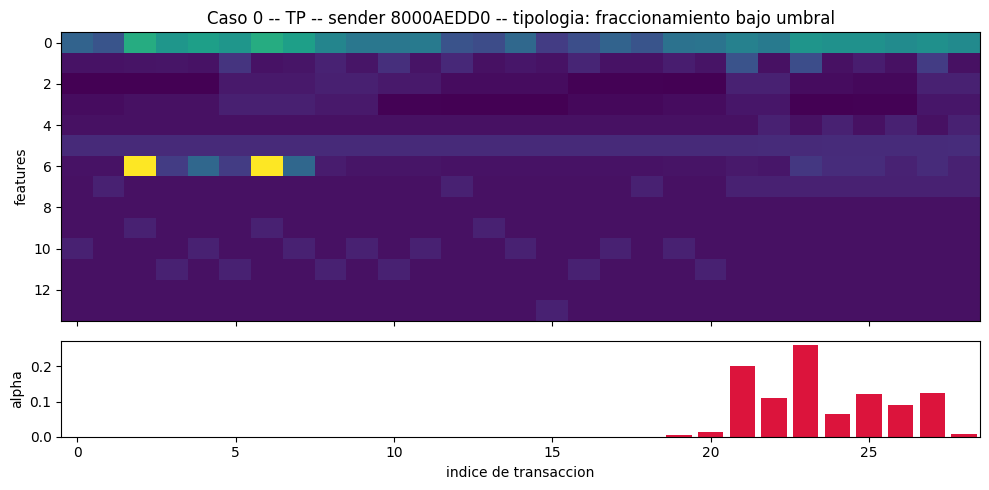

Top-3 transacciones con mayor atencion -- caso 0:
 idx    alpha  log_amount  delta_t  is_new_dest
  23 0.260099   10.101928 4.030991          0.0
  21 0.201963    8.339978 4.447346          0.0
  27 0.123438    9.684484 2.770503          0.0



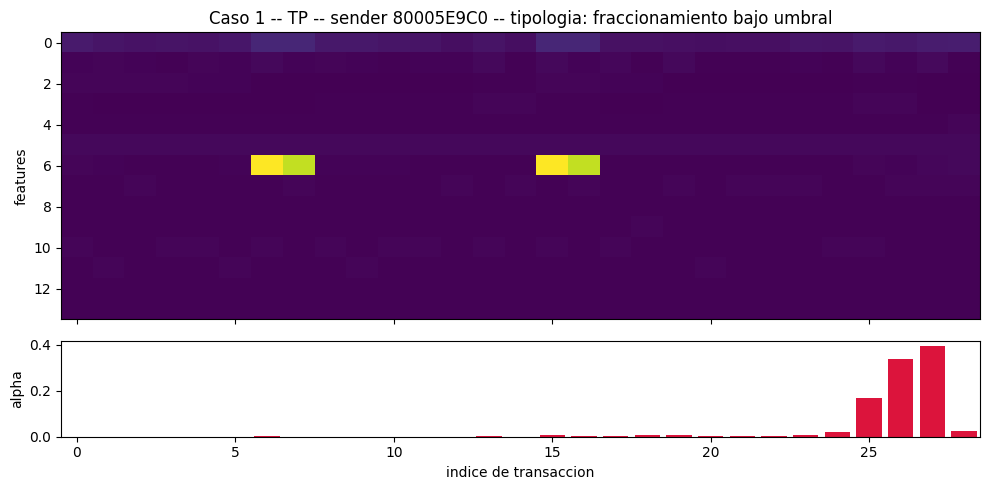

Top-3 transacciones con mayor atencion -- caso 1:
 idx    alpha  log_amount  delta_t  is_new_dest
  27 0.397226    9.673655 2.731116          0.0
  26 0.338791    8.276697 0.168335          0.0
  25 0.170914    9.096875 1.907070          0.0



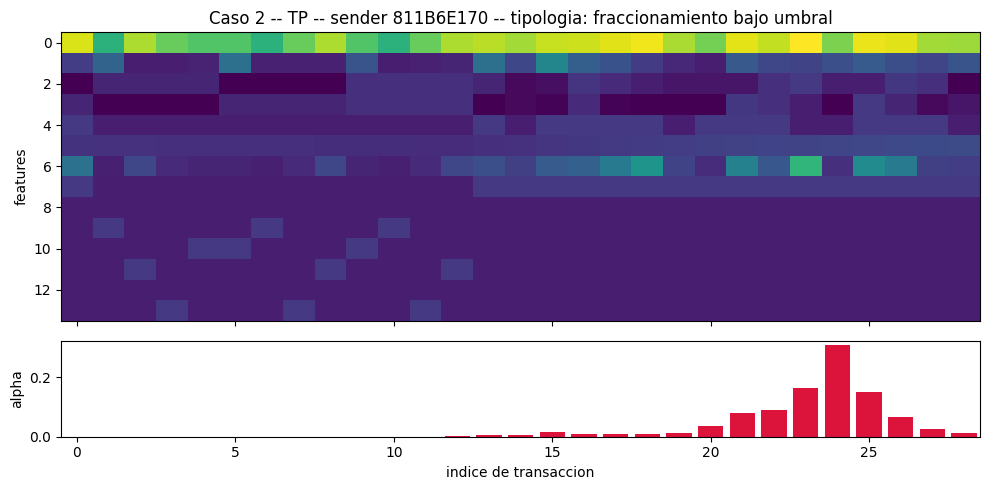

Top-3 transacciones con mayor atencion -- caso 2:
 idx    alpha  log_amount  delta_t  is_new_dest
  24 0.308804    8.760925 1.974081          0.0
  23 0.163487   11.159576 1.474000          0.0
  25 0.151871   10.795527 2.490447          1.0



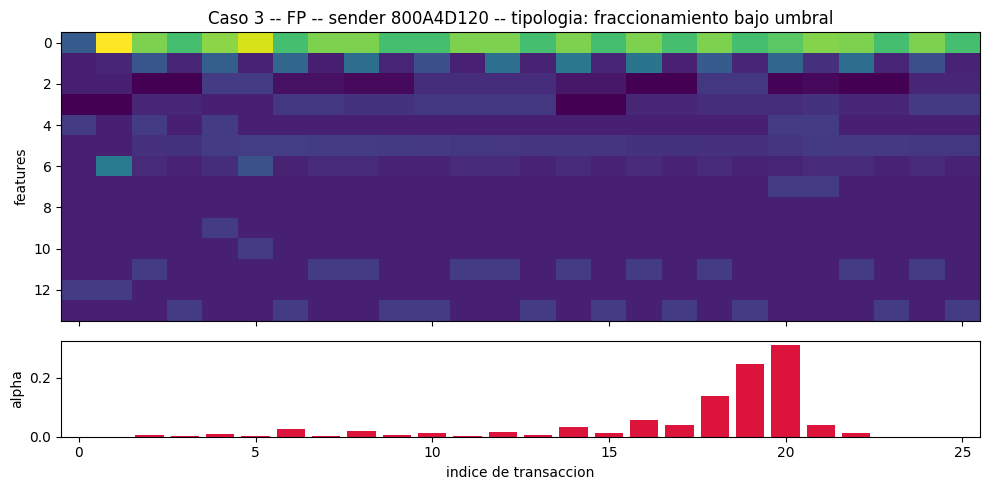

Top-3 transacciones con mayor atencion -- caso 3:
 idx    alpha  log_amount  delta_t  is_new_dest
  20 0.310644    7.582474 2.818398          1.0
  19 0.245192    7.122560 0.223144          0.0
  18 0.137159    8.245582 2.346602          0.0



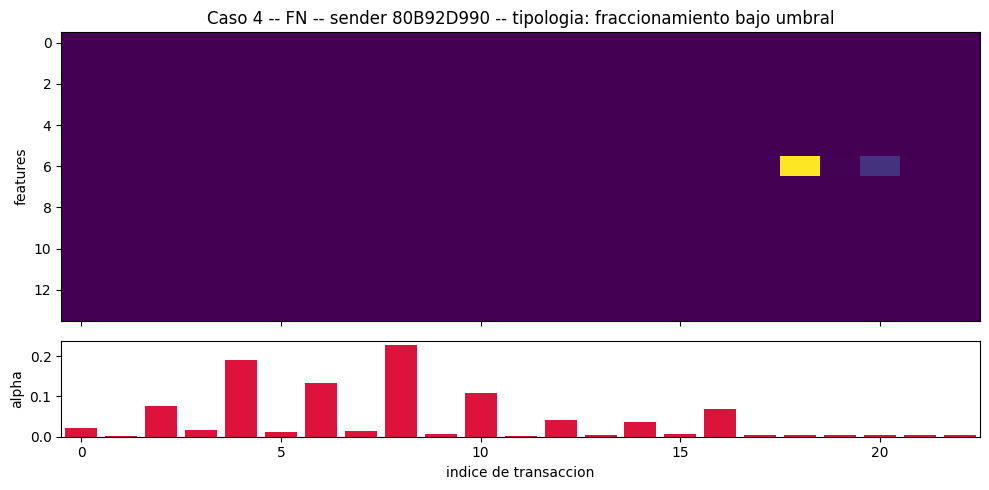

Top-3 transacciones con mayor atencion -- caso 4:
 idx    alpha  log_amount  delta_t  is_new_dest
   8 0.227363    9.823677 3.378725          0.0
   4 0.189521    9.718159 3.563411          0.0
   6 0.134638    9.718159 3.035754          0.0



In [29]:
# Figura por caso: secuencia de transacciones con alpha superpuesto como mapa
# de calor, mas tabla de las 3 transacciones con mayor atencion.
for case_num, local_i in enumerate(selected_local):
    global_i = test_idx[local_i]
    valid = mask[global_i]
    feats = X[global_i][valid]
    alpha_valid = alpha_test[local_i][valid]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5), sharex=True,
                                    gridspec_kw={"height_ratios": [3, 1]})
    ax1.imshow(feats.T, aspect="auto", cmap="viridis")
    ax1.set_ylabel("features")
    ax1.set_title(f"Caso {case_num} -- {case_summaries[case_num]['tipo_caso']} -- "
                   f"sender {case_summaries[case_num]['sender_id']} -- "
                   f"tipologia: {case_summaries[case_num]['tipologia_heuristica']}")
    ax2.bar(range(len(alpha_valid)), alpha_valid, color="crimson")
    ax2.set_ylabel("alpha")
    ax2.set_xlabel("indice de transaccion")
    plt.tight_layout()
    plt.show()

    top3_attn = np.argsort(-alpha_valid)[:3]
    tx_table = pd.DataFrame({
        "idx": top3_attn,
        "alpha": alpha_valid[top3_attn],
        "log_amount": feats[top3_attn, feature_cols.index("log_amount")],
        "delta_t": feats[top3_attn, feature_cols.index("delta_t")],
        "is_new_dest": feats[top3_attn, feature_cols.index("is_new_dest")],
    })
    print(f"Top-3 transacciones con mayor atencion -- caso {case_num}:")
    print(tx_table.to_string(index=False))
    print()


**Nota metodologica sobre la tipologia heuristica:** en la corrida de
referencia, los 5 casos seleccionados recibieron la misma etiqueta,
"fraccionamiento bajo umbral" (y lo mismo ocurre con 1,110 de los 2,000
remitentes exportados al MVP). Revisando la regla (`tipologia()`, seccion 9),
esto expone una limitacion real de la heuristica: la condicion
`threshold_ratio > 0.8` (monto > $8,000) dispara con **cualquier** transaccion
grande, no solo con montos agrupados justo debajo de un umbral regulatorio
(p. ej. $9,000-$9,900 si el umbral es $10,000). Una version mejorada acotaria el
rango (`0.8 < threshold_ratio < 1.0`). Se deja documentado como limitacion
conocida en vez de ocultarlo, y el analisis de abajo interpreta los datos reales
de cada caso en lugar de confiar en esa etiqueta.

**Como leer la atencion:** `alpha` indica cuanto peso dio el modelo a cada
transaccion al construir el vector que alimenta el clasificador. No prueba que
una transaccion sea ilicita ni identifica una causa; es una pista de donde mirar.
Las etiquetas de IBM AML son por transaccion, pero el proyecto etiqueta por
remitente, asi que no se puede decir cual transaccion concreta es la ilicita.
Umbrales de esta corrida: Etapa A = 1.269 (score de anomalia) y Etapa B = 0.334
(probabilidad), ambos fijados en validacion.

**Caso 0 -- Verdadero positivo (sender `8000AEDD0`, prob_b=0.982,
recon_error=1.10):** 29 transacciones, 11 de ellas de $10,000 o mas. La atencion
(top-3 = 59%) cae en el tramo final: una transferencia ACH de $24.4k tras 55 h de
inactividad (alpha=0.26), una de $4.2k tras 84 h (0.20) y una de $16.1k (0.12), las
tres hacia la propia cuenta del remitente. Los ultimos 8 movimientos (indices
21-28) son todos ACH de $2.5k a $24.4k, mientras que el historial previo mezcla
cheques, tarjeta, efectivo y wire. Ademas hay montos identicos repetidos
($203,402.36, $61,128.98 y $27,815.69, cada uno dos veces). La lectura es un
cambio de canal con escalada de montos sobre un historial con repeticiones
exactas, mas cercano a *layering* que a fraccionamiento (solo 1 transaccion cae
entre $8,000 y $10,000). El score de la Etapa A (1.10) queda **por debajo** de su
umbral: la alerta la sostiene la Etapa B.

**Caso 1 -- Verdadero positivo (sender `80005E9C0`, prob_b=0.978,
recon_error=0.72):** atencion muy concentrada (top-3 = 91%) en el cierre de la
secuencia: una ACH de $15.9k a la propia cuenta (alpha=0.40), una ACH de $3.9k a
las 23 h, unos 11 minutos despues de la anterior (0.34), y un cheque de $8.9k a la
misma contraparte (0.17). Antes hay dos pares identicos de montos extremos (cheque
de $1,396,477.49 seguido de ACH de $1,267,055.71, repetidos en los indices 6-7 y
15-16) y el monto de $8,926.35 aparece dos veces (indices 0 y 25). Una observacion
que el modelo **no** usa: la ultima transaccion (indice 28, $22.5k, alpha=0.02) va
a `8000AEDD0`, que es el remitente del caso 0, tambien con lavado. Es una pista de
red entre dos casos que un modelo que analiza cada remitente por separado no puede
aprovechar (motivo para explorar enfoques con grafos). Score de Etapa A bajo el
umbral: de nuevo decide la Etapa B.

**Caso 2 -- Verdadero positivo (sender `811B6E170`, prob_b=0.958,
recon_error=1.50):** es el unico de los tres verdaderos positivos en que **ambas**
etapas alertan (1.50 > 1.269). 29 transacciones hacia 15 destinos distintos, 12
marcados como destino nuevo, y 18 de $10,000 o mas. Los indices 1 al 12 repiten tres
veces el mismo ciclo de cuatro montos ($892.95, $16,005.31, $4,253.48 y $2,583.32)
en cuatro canales distintos, casi siempre con intervalos de minutos; despues vienen 16
transferencias ACH de $5.6k a $70.2k con intervalos de 0 a 95 h, muchas a destinos
nuevos. La atencion (top-3 = 62%) se reparte entre una ACH de $6.4k (0.31), una de
$70.2k (0.16) y una de $48.8k a un destino nuevo a las 0 h (0.15). Es el patron que
mejor encaja con *abanico de destinos* (dispersion a muchas contrapartes) sobre un
"guion" repetitivo, y no con fraccionamiento.

**Caso 3 -- Falso positivo (sender `800A4D120`, prob_b=0.605, recon_error=1.38):**
alertan ambas etapas (0.605 > 0.334 y 1.38 > 1.269) y aun asi la etiqueta es
"normal". Este remitente no esta entre los 2,000 exportados al MVP, asi que solo se
dispone de la tabla de atencion: el 31% cae en una transaccion de ~$1,962 a un
destino nuevo (indice 20), el 25% en una de ~$1,239 ocurrida solo 15 minutos antes
(indice 19) y el 14% en una de ~$3,810 (indice 18). No hay montos extremos: lo que
el modelo parece haber captado es la combinacion "rafaga corta de transacciones
moderadas + destino nuevo". Una hipotesis plausible es actividad legitima con esa
misma firma (por ejemplo pagos agrupados a proveedores), pero con estos datos no se
puede verificar; sin datos KYC un analista tampoco podria descartarla sin
investigar. Ilustra directamente el costo del falso positivo que describe el
enunciado.

**Caso 4 -- Falso negativo (sender `80B92D990`, prob_b=0.040, recon_error=0.51, el
mas bajo de los 5):** las dos etapas lo consideran normal. Las primeras 18
transacciones alternan **exactamente** dos montos, $16,615.62 (tarjeta) y $18,464.82
(cheque), nueve veces cada uno, hacia solo 3 destinos: una regularidad casi perfecta
que el autoencoder reconstruye con error muy bajo (para la Etapa A, lo mas
predecible es lo mas normal). Lo mas llamativo es que en los indices 18-20 hay una
rafaga de tres ACH a las 23 h por **$201,934,723.44, $939,285.29 y $29,211,025.78**,
varios ordenes de magnitud sobre el resto de la secuencia, y el modelo les asigna en
total solo 1.4% de la atencion (0.005 cada una); su atencion se queda en el patron
repetitivo (top-3 = 55%, sobre las transacciones 4, 6 y 8). Como el remitente tiene
23 transacciones (menos que `MAX_LEN=29`), todo su historial esta dentro de la
ventana visible: no es un problema de truncamiento. Esta es la falla mas importante
del sistema: una secuencia muy regular parece "normal" para el autoencoder y el
clasificador no aprendio a reaccionar ante una rafaga de montos extremos cuando esta
rodeada de un patron repetitivo. Recomendacion para produccion: complementar el
modelo con reglas simples de monto extremo, que hubieran capturado este caso.


## 10. Exportacion de artefactos

In [30]:
os.makedirs("checkpoints", exist_ok=True)
os.makedirs("artifacts", exist_ok=True)

torch.save(ae_model.state_dict(), "checkpoints/stage_a.pt")
torch.save(final_model.state_dict(), "checkpoints/stage_b.pt")

for name, path in [("stage_a.pt", "checkpoints/stage_a.pt"), ("stage_b.pt", "checkpoints/stage_b.pt")]:
    size_mb = os.path.getsize(path) / 1e6
    print(f"{name}: {size_mb:.2f} MB")


stage_a.pt: 0.34 MB
stage_b.pt: 0.35 MB


In [31]:
preprocessing = dict(
    CFG={k: v for k, v in CFG.items()},
    norm_stats=norm_stats,
    feature_cols=feature_cols,
    max_len=int(max_len),
)
with open("artifacts/preprocessing.json", "w") as f:
    json.dump(preprocessing, f, indent=2, default=str)

metrics_final = dict(
    ablation_summary=ablation_df.to_dict(orient="records"),
    threshold_f2=float(thr_f2),
    threshold_alert_rate=float(thr_alert),
    official_threshold=float(official_threshold),
    threshold_b=float(alert_thr),
    alert_rate=CFG["ALERT_RATE"],
)
with open("artifacts/metrics.json", "w") as f:
    json.dump(metrics_final, f, indent=2, default=str)

print("preprocessing.json y metrics.json escritos.")


preprocessing.json y metrics.json escritos.


In [32]:
# Agrupar una sola vez (O(n)) en vez de filtrar df_valid completo por cada
# remitente de test dentro del loop (O(n) por remitente -> O(n * n_test), que
# en una corrida real con sender_id de tipo string tomo minutos).
sender_groups = {sid: g for sid, g in df_valid.groupby("sender_id", sort=False)}

mvp_records = []
for local_i in range(len(test_idx)):
    global_i = test_idx[local_i]
    sid = sender_ids[global_i]
    L = int(mask[global_i].sum())

    g = sender_groups[sid].sort_values("timestamp").tail(max_len)
    tx_cols_export = g[["amount", "tx_type", "hour", "delta_t_h", "dest_id", "is_new_dest"]].to_dict("records")
    txs = [
        dict(idx=j, amount=float(r["amount"]), type=str(r["tx_type"]),
             hour=int(r["hour"]), delta_t_h=float(r["delta_t_h"]),
             dest_id=str(r["dest_id"]), is_new_dest=int(r["is_new_dest"]))
        for j, r in enumerate(tx_cols_export)
    ]

    alpha_valid = alpha_test[local_i][mask[global_i]].tolist()
    tipo = tipologia(X[global_i], feature_cols, alpha_test[local_i], mask[global_i])

    mvp_records.append(dict(
        sender_id=str(sid),
        transactions=txs,
        recon_error=float(recon_test[local_i]),
        anomaly_score_a=float(recon_test[local_i]),
        prob_b=float(probs_test[local_i]),
        attention=alpha_valid,
        label=int(labels_test[local_i]),
        pred=int(preds_test[local_i]),
        tipologia=tipo,
    ))

mvp_json_path = "artifacts/mvp_data.json"
with open(mvp_json_path, "w") as f:
    json.dump(mvp_records, f)

size_mb = os.path.getsize(mvp_json_path) / 1e6
print(f"Tamano inicial de mvp_data.json: {size_mb:.1f} MB, {len(mvp_records)} remitentes")

if size_mb > 25:
    pos_records = [r for r in mvp_records if r["label"] == 1]
    neg_records = [r for r in mvp_records if r["label"] == 0]
    rng = np.random.RandomState(0)
    n_neg_keep = max(2000 - len(pos_records), 0)
    keep_idx = rng.choice(len(neg_records), size=min(n_neg_keep, len(neg_records)), replace=False)
    mvp_records = pos_records + [neg_records[i] for i in keep_idx]
    with open(mvp_json_path, "w") as f:
        json.dump(mvp_records, f)
    new_size_mb = os.path.getsize(mvp_json_path) / 1e6
    print(f"Submuestreado a {len(mvp_records)} remitentes (todos los positivos + "
          f"negativos aleatorios) por limite de tamano. Nuevo tamano: {new_size_mb:.1f} MB")


Tamano inicial de mvp_data.json: 30.5 MB, 9002 remitentes
Submuestreado a 2000 remitentes (todos los positivos + negativos aleatorios) por limite de tamano. Nuevo tamano: 6.7 MB


In [33]:
expected_files = [
    "checkpoints/stage_a.pt", "checkpoints/stage_b.pt",
    "artifacts/preprocessing.json", "artifacts/metrics.json",
    "artifacts/ablation.csv", "artifacts/mvp_data.json",
]
for f in expected_files:
    exists = os.path.exists(f)
    size_kb = os.path.getsize(f) / 1024 if exists else 0
    print(f"{'OK ' if exists else 'FALTA '}{f} ({size_kb:.1f} KB)")
assert all(os.path.exists(f) for f in expected_files), "Faltan artefactos por exportar"


OK checkpoints/stage_a.pt (333.4 KB)
OK checkpoints/stage_b.pt (343.7 KB)
OK artifacts/preprocessing.json (1.5 KB)
OK artifacts/metrics.json (4.1 KB)
OK artifacts/ablation.csv (1.8 KB)
OK artifacts/mvp_data.json (6582.9 KB)


## 11. Conexion con el curso

**S3 -- RNN y LSTM.** `SeqEncoder` usa una GRU bidireccional, no una RNN
vanilla. La razon es directamente la que motiva el LSTM/GRU en S3: en una RNN
simple, $\partial h_t/\partial h_{t-1} = W_h^\top \text{diag}(1-h_t^2)$, y ese
producto se desvanece exponencialmente con la distancia si $\|W_h\| < 1$. Con
secuencias de hasta `MAX_LEN=29` transacciones (el valor real derivado del
percentil 90 en la corrida de referencia; ver nota en la celda de Decision de
la seccion 3), una RNN vanilla perderia la
señal de las transacciones mas antiguas antes de llegar al final de la
secuencia. La GRU (variante de LSTM con dos compuertas) mantiene una ruta de
gradiente mas directa, analoga a $\partial c_t/\partial c_{t-1} = f_t$ del
LSTM, evitando ese desvanecimiento.

**S4 -- Encoder-Decoder y Autoencoders.** La Etapa A es, literalmente, el
autoencoder de S4 aplicado a secuencias: $z = f_{enc}(x;\theta_{enc})$,
$\hat x = f_{dec}(z;\theta_{dec})$, entrenado minimizando una version
enmascarada de $L = \frac1d\|x-\hat x\|^2$. S4 menciona explicitamente
"deteccion de fraude" como aplicacion de autoencoders -- es exactamente el uso
que se le da aqui. Ademas, el problema que obligo a rediseñar `SeqDecoder`
(documentado en la celda de Decision de la seccion 6) es el mismo "cuello de
botella del vector de contexto" que describe S4: un $z$ fijo que debe resumir
toda la secuencia hace que el decoder "olvide" el detalle si no recibe mas
señal en cada paso. La solucion aplicada -- alimentar $x_{t-1}$ en cada paso
del decoder (teacher forcing) -- es la misma idea de S4's Seq2Seq: el decoder
consume la salida del paso anterior, no solo un vector de contexto estatico.

**S5 -- Attention.** `AttnPool` es una atencion aditiva (Bahdanau):
$e_t = v^\top\tanh(Wh_t)$, $\alpha = \text{softmax}(e)$ con $\sum_t \alpha_t = 1$
(verificado con un assert numerico en la seccion 9), y contexto
$z = \sum_t \alpha_t h_t$ -- exactamente la formula de S5,
$\tilde{\mathbf c}_s = \sum_t \alpha_{s,t}\mathbf v_t$. La diferencia con el S5
"clasico" es que aqui no hay un decoder generando un query distinto en cada
paso: es una atencion de *pooling*, con un query aprendido implicitamente en
$(W, v)$, que resume toda la secuencia en un solo vector. Es tambien la pieza
que hace posible la interpretabilidad de la seccion 9: como explica S5, el
gradiente (y aqui, la señal de importancia) llega directo a cada
$h_t^{enc}$ sin atravesar toda la recurrencia, por eso $\alpha$ puede leerse
como "cuanto peso puso el modelo en cada transaccion".

**S8 -- Perdidas, Regularizacion y Optimizacion.** La focal loss de la Etapa B
se implemento a mano siguiendo exactamente la formula de S8,
$\mathcal L_{focal} = -\alpha(1-\hat y)^\gamma\log\hat y$, que S8 recomienda
puntualmente para "clases muy desbalanceadas" -- el caso extremo de AML (1626
positivos de 128,779 remitentes validos, ~1.3%). La justificacion de AUPRC
sobre ROC-AUC en la seccion 8 del notebook es la misma logica que motiva la
focal loss en S8: con desbalance severo, las metricas/perdidas que tratan
todos los errores por igual (ROC-AUC, BCE plana) se vuelven poco informativas.
Tambien de S8: Adam como optimizador por defecto en ambas etapas, y
`nn.Dropout(0.2)` en `DetectorHead` como regularizacion de la cabeza de
clasificacion.

**S9 -- Transfer Learning y Fine-Tuning.** La Etapa B implementa, en
secuencia, dos de las tres estrategias de adaptacion de S9 sobre el mismo
encoder: durante `FREEZE_EPOCHS` se usa "feature extraction" tal cual la
describe S9 (`requires_grad=False` sobre todo el backbone, solo se entrena la
cabeza), y despues se pasa a "fine-tuning completo" (se descongela el
encoder). Esto es precisamente el "protocolo gradual" de S9: entrenar cabeza
-> descongelar el resto. `LR_HEAD` vs. `LR_ENCODER` (~3x mas bajo: 1e-3 vs. 3e-4) es un
learning rate diferencial de manual: mismo patron que S9 describe para mitigar
*catastrophic forgetting* al hacer fine-tuning completo. El propio resultado
de la ablacion (config 3 "congelado" muy por debajo de config 4/5
"fine-tuning") es una confirmacion empirica de la regla de S9 sobre *domain
shift*: pasar de "aprender que es normal" (objetivo no supervisado) a
"predecir lavado" (objetivo supervisado) es un shift de dominio moderado a
severo -- **no** es el caso de "dataset pequeño + dominio similar" donde S9
dice que feature extraction basta; por eso solo el fine-tuning completo recupera el desempeño del baseline supervisado (config 4: AUPRC 0.379 frente a 0.398). Solo al añadir la reconstruccion como feature (config 5) mejora el ROC-AUC (0.858 frente a 0.830), sin superar de forma consistente al baseline en AUPRC ni en precision@1% (ver la lectura de la ablacion en la seccion 8).


In [34]:
total_time = time.time() - NOTEBOOK_START
print(f"Tiempo total de ejecucion del notebook: {total_time:.1f}s ({total_time / 60:.1f} min)")
assert total_time < 30 * 60, "El notebook supero el limite de 30 minutos"


Tiempo total de ejecucion del notebook: 1070.5s (17.8 min)
